In [1]:
import pandas as pd
from scipy.io import arff
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

import random
import numpy as np
import torch

from torch.utils.data import TensorDataset, DataLoader

import torch
import torch.nn as nn
import torch.nn.functional as F

from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

# EDA

In [2]:
# Load ARFF
data, meta = arff.loadarff("adult.arff")

df = pd.DataFrame(data)

# Decode byte strings
for col in df.columns:
    if df[col].dtype == object:
        df[col] = df[col].str.decode("utf-8")

print("Shape:")
print(df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nDtypes:")
print(df.dtypes)

print("\nFirst rows:")
display(df.head())

Shape:
(32561, 15)

Columns:
['age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income']

Dtypes:
age               float64
workclass          object
fnlwgt            float64
education          object
education-num     float64
marital-status     object
occupation         object
relationship       object
race               object
sex                object
capital-gain      float64
capital-loss      float64
hours-per-week    float64
native-country     object
income             object
dtype: object

First rows:


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39.0,State-gov,77516.0,Bachelors,13.0,Never-married,Adm-clerical,Not-in-family,White,Male,2174.0,0.0,40.0,United-States,<=50K
1,50.0,Self-emp-not-inc,83311.0,Bachelors,13.0,Married-civ-spouse,Exec-managerial,Husband,White,Male,0.0,0.0,13.0,United-States,<=50K
2,38.0,Private,215646.0,HS-grad,9.0,Divorced,Handlers-cleaners,Not-in-family,White,Male,0.0,0.0,40.0,United-States,<=50K
3,53.0,Private,234721.0,11th,7.0,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0.0,0.0,40.0,United-States,<=50K
4,28.0,Private,338409.0,Bachelors,13.0,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0.0,0.0,40.0,Cuba,<=50K


In [3]:
print(df.isna().sum())

# Sometimes Adult uses '?' instead of NaN
for col in df.columns:
    if df[col].dtype == object:
        n_q = (df[col] == "?").sum()
        if n_q > 0:
            print(f"{col}: {n_q} '?' values")

age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
income            0
dtype: int64
workclass: 1836 '?' values
occupation: 1843 '?' values
native-country: 583 '?' values


In [4]:
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39.0,State-gov,77516.0,Bachelors,13.0,Never-married,Adm-clerical,Not-in-family,White,Male,2174.0,0.0,40.0,United-States,<=50K
1,50.0,Self-emp-not-inc,83311.0,Bachelors,13.0,Married-civ-spouse,Exec-managerial,Husband,White,Male,0.0,0.0,13.0,United-States,<=50K
2,38.0,Private,215646.0,HS-grad,9.0,Divorced,Handlers-cleaners,Not-in-family,White,Male,0.0,0.0,40.0,United-States,<=50K
3,53.0,Private,234721.0,11th,7.0,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0.0,0.0,40.0,United-States,<=50K
4,28.0,Private,338409.0,Bachelors,13.0,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0.0,0.0,40.0,Cuba,<=50K


In [5]:
categorical_cols = []
continuous_cols = []

for col in df.columns:
    if df[col].dtype == object:
        categorical_cols.append(col)
    else:
        continuous_cols.append(col)

print("Categorical:")
print(categorical_cols)

print("\nContinuous:")
print(continuous_cols)

Categorical:
['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country', 'income']

Continuous:
['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']


In [6]:
for col in categorical_cols:
    print(f"\n{col}")
    print(f"unique={df[col].nunique()}")
    print(df[col].value_counts().head())


workclass
unique=9
workclass
Private             22696
Self-emp-not-inc     2541
Local-gov            2093
?                    1836
State-gov            1298
Name: count, dtype: int64

education
unique=16
education
HS-grad         10501
Some-college     7291
Bachelors        5355
Masters          1723
Assoc-voc        1382
Name: count, dtype: int64

marital-status
unique=7
marital-status
Married-civ-spouse    14976
Never-married         10683
Divorced               4443
Separated              1025
Widowed                 993
Name: count, dtype: int64

occupation
unique=15
occupation
Prof-specialty     4140
Craft-repair       4099
Exec-managerial    4066
Adm-clerical       3770
Sales              3650
Name: count, dtype: int64

relationship
unique=6
relationship
Husband          13193
Not-in-family     8305
Own-child         5068
Unmarried         3446
Wife              1568
Name: count, dtype: int64

race
unique=5
race
White                 27816
Black                  3124
Asian-Pac

In [7]:
display(df[continuous_cols].describe())

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


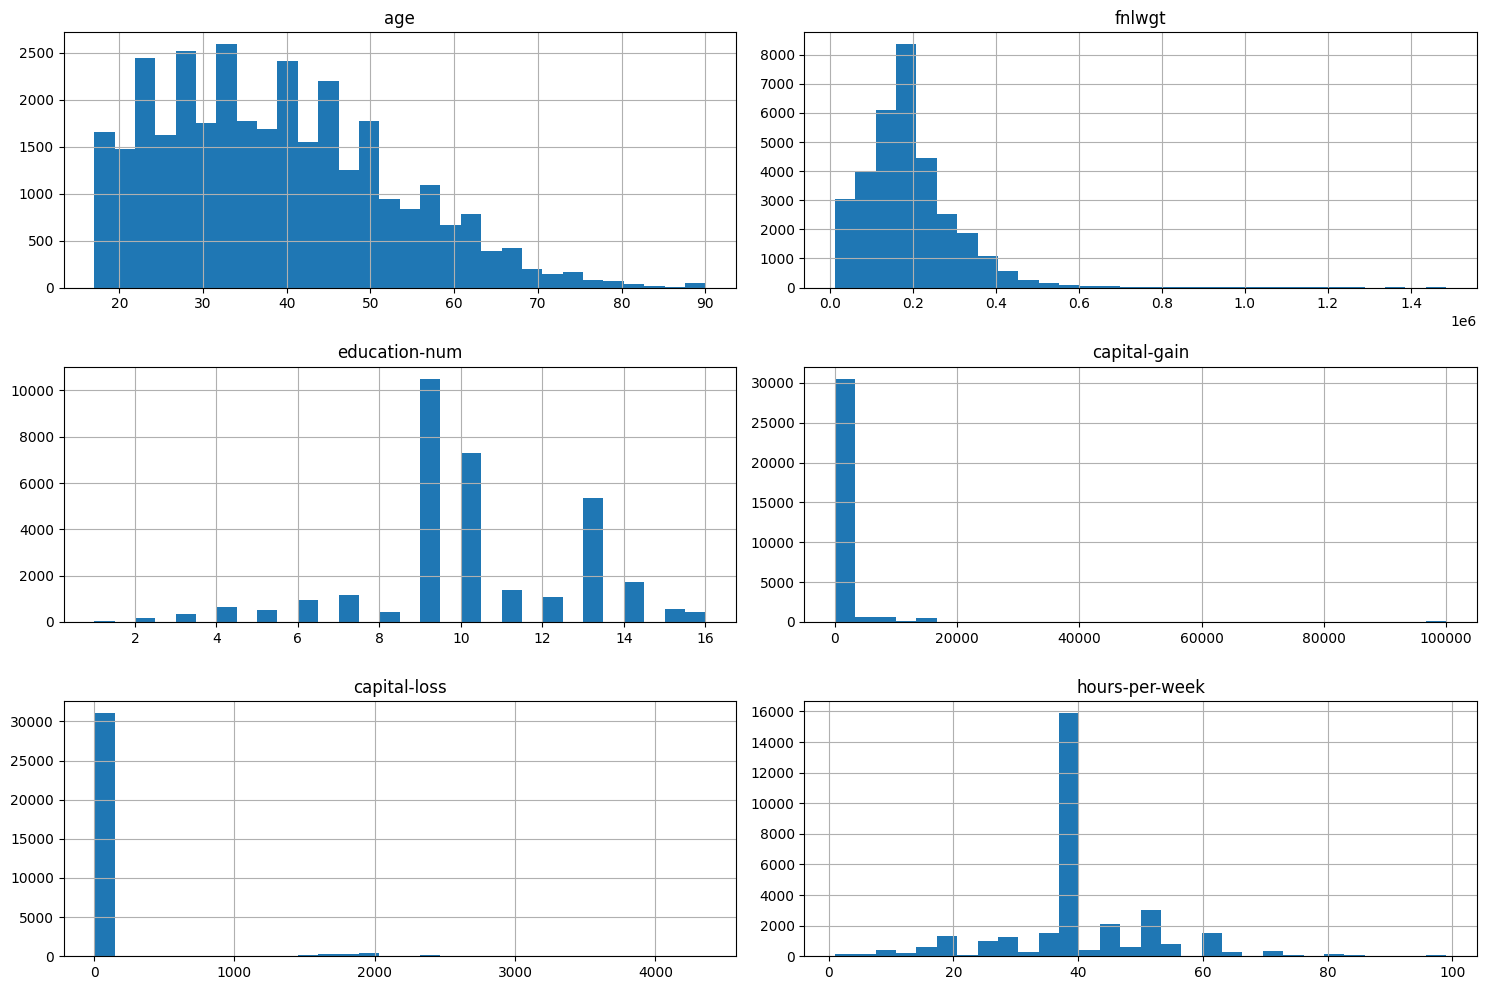

In [8]:
df[continuous_cols].hist(
    figsize=(15, 10),
    bins=30
)

plt.tight_layout()
plt.show()

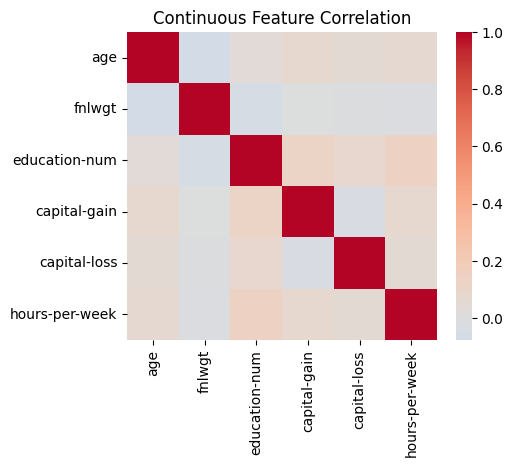

In [9]:
corr = df[continuous_cols].corr()

plt.figure(figsize=(5,4))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Continuous Feature Correlation")
plt.show()

# Preprocessing

In [10]:
continuous_cols = [
    "age",
    "fnlwgt",
    "education-num",
    "capital-gain",
    "capital-loss",
    "hours-per-week"
]

categorical_cols = [
    "workclass",
    "education",
    "marital-status",
    "occupation",
    "relationship",
    "race",
    "sex",
    "native-country"
]

In [11]:
# replace missing values
df = df.replace("?", "Unknown")

target_col = "income"

X = df.drop(columns=[target_col])
y = (df[target_col] == ">50K").astype(int)

In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [13]:
preprocessor = ColumnTransformer(
    [
        ("num", StandardScaler(), continuous_cols),
        (
            "cat",
            OneHotEncoder(
                sparse_output=False,
                handle_unknown="ignore"
            ),
            categorical_cols
        ),
    ]
)

In [14]:
def postprocess_synthetic_tabular(X_synth, n_cont, cat_dims):
    X_fixed = X_synth.copy()

    start = n_cont
    for dim in cat_dims:
        block = X_fixed[:, start:start + dim]
        idx = np.argmax(block, axis=1)

        block_fixed = np.zeros_like(block)
        block_fixed[np.arange(len(block)), idx] = 1

        X_fixed[:, start:start + dim] = block_fixed
        start += dim

    return X_fixed

# Model Classes

In [15]:
class Generator(nn.Module):
    def __init__(self, noise_dim, output_dim):
        super().__init__()
        
        self.net = nn.Sequential(
            nn.Linear(noise_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),

            nn.Linear(256, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),

            nn.Linear(512, output_dim)
        )

    def forward(self, z):
        return self.net(z)


class Discriminator(nn.Module):
    def __init__(self, input_dim):
        super().__init__()

        self.features = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 128),
            nn.LeakyReLU(0.2)
        )

        self.classifier = nn.Sequential(
            nn.Linear(128, 1),
            # nn.Sigmoid()
        )

    def forward(self, x, return_features=False):
        feat = self.features(x)
        out = self.classifier(feat)

        if return_features:
            return out, feat

        return out

In [16]:
class ConditionalGenerator(nn.Module):
    def __init__(self, noise_dim, condition_dim, output_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(noise_dim + condition_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, output_dim),
            # nn.Sigmoid()
        )

    def forward(self, z, y_cond):
        x = torch.cat([z, y_cond.float()], dim=1)
        return self.net(x)


class ConditionalDiscriminator(nn.Module):
    def __init__(self, input_dim, condition_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim + condition_dim, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 128),
            nn.LeakyReLU(0.2),
            nn.Linear(128, 1),
            # nn.Sigmoid()
        )

    def forward(self, x, y_cond):
        x = torch.cat([x, y_cond.float()], dim=1)
        return self.net(x)

In [17]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

# Utils

In [18]:
def train_gan(
    train_loader,
    input_dim,
    noise_dim,
    device,
    num_epochs=50,
    lr_g=2e-4,
    lr_d=1e-4,
    label_smoothing=False
):
    G = Generator(noise_dim, input_dim).to(device)
    D = Discriminator(input_dim).to(device)

    criterion = nn.BCEWithLogitsLoss()

    optimizer_G = torch.optim.Adam(
        G.parameters(),
        lr=lr_g,
        betas=(0.5, 0.999)
    )

    optimizer_D = torch.optim.Adam(
        D.parameters(),
        lr=lr_d,
        betas=(0.5, 0.999)
    )

    G_losses = []
    D_losses = []

    for epoch in range(num_epochs):
        epoch_G_loss = 0.0
        epoch_D_loss = 0.0

        for (real_batch,) in train_loader:
            real_batch = real_batch.to(device)
            batch_size = real_batch.size(0)

            if label_smoothing:
                real_labels = torch.empty(batch_size, 1, device=device).uniform_(0.8, 1.0)
                fake_labels = torch.empty(batch_size, 1, device=device).uniform_(0.0, 0.1)
            else:
                real_labels = torch.ones(batch_size, 1, device=device)
                fake_labels = torch.zeros(batch_size, 1, device=device)

            # -----------------
            # Train Discriminator
            # -----------------
            z = torch.randn(batch_size, noise_dim, device=device)
            fake_batch = G(z).detach()

            D_real = D(real_batch)
            D_fake = D(fake_batch)

            D_loss_real = criterion(D_real, real_labels)
            D_loss_fake = criterion(D_fake, fake_labels)
            D_loss = D_loss_real + D_loss_fake

            optimizer_D.zero_grad()
            D_loss.backward()
            optimizer_D.step()

            # -----------------
            # Train Generator
            # -----------------
            z = torch.randn(batch_size, noise_dim, device=device)
            fake_batch = G(z)

            D_fake = D(fake_batch)
            G_loss = criterion(D_fake, real_labels)

            optimizer_G.zero_grad()
            G_loss.backward()
            optimizer_G.step()

            epoch_D_loss += D_loss.item()
            epoch_G_loss += G_loss.item()

        epoch_D_loss /= len(train_loader)
        epoch_G_loss /= len(train_loader)

        D_losses.append(epoch_D_loss)
        G_losses.append(epoch_G_loss)

        if (epoch + 1) % 10 == 0:
            print(
                f"Epoch [{epoch+1}/{num_epochs}] "
                f"D_loss: {epoch_D_loss:.4f} "
                f"G_loss: {epoch_G_loss:.4f}"
            )

    return G, D, G_losses, D_losses

In [19]:
def generate_synthetic(
    G,
    n_samples,
    noise_dim,
    device,
    batch_size=1024
):
    G.eval()
    synth_batches = []

    with torch.no_grad():
        for start in range(0, n_samples, batch_size):
            curr_bs = min(batch_size, n_samples - start)
            z = torch.randn(curr_bs, noise_dim, device=device)
            fake = G(z)
            synth_batches.append(fake.cpu().numpy())

    return np.vstack(synth_batches)

In [20]:
def run_detection_auc(
    X_real,
    X_synth,
    n_splits=4,
    random_state=42
):
    X_det = np.vstack([X_real, X_synth])

    y_det = np.concatenate([
        np.zeros(len(X_real)),
        np.ones(len(X_synth))
    ])

    skf = StratifiedKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=random_state
    )

    aucs = []

    for train_idx, test_idx in skf.split(X_det, y_det):
        X_tr = X_det[train_idx]
        X_te = X_det[test_idx]

        y_tr = y_det[train_idx]
        y_te = y_det[test_idx]

        rf = RandomForestClassifier(
            n_estimators=200,
            random_state=random_state,
            n_jobs=-1
        )

        rf.fit(X_tr, y_tr)

        probs = rf.predict_proba(X_te)[:, 1]
        auc = roc_auc_score(y_te, probs)

        aucs.append(auc)

    return float(np.mean(aucs))

In [21]:
def run_efficacy(
    X_synth,
    y_synth,
    X_train,
    y_train,
    X_test,
    y_test,
    random_state=42
):
    rf_real = RandomForestClassifier(
        n_estimators=300,
        random_state=random_state,
        n_jobs=-1
    )

    rf_real.fit(X_train, y_train)
    real_probs = rf_real.predict_proba(X_test)[:, 1]
    auc_real = roc_auc_score(y_test, real_probs)

    rf_synth = RandomForestClassifier(
        n_estimators=300,
        random_state=random_state,
        n_jobs=-1
    )

    rf_synth.fit(X_synth, y_synth)
    synth_probs = rf_synth.predict_proba(X_test)[:, 1]
    auc_synth = roc_auc_score(y_test, synth_probs)

    efficacy = auc_synth / auc_real

    return float(auc_synth), float(auc_real), float(efficacy)

In [22]:
def train_cgan(
    X_train,
    y_train,
    input_dim,
    noise_dim,
    condition_dim,
    device,
    num_epochs=50,
    batch_size=128,
    lr_g=2e-4,
    lr_d=1e-4,
    label_smoothing=False
):
    y_train = np.asarray(y_train).astype(int)

    X_tensor = torch.tensor(X_train, dtype=torch.float32)
    y_tensor = torch.tensor(y_train, dtype=torch.long)

    dataset = TensorDataset(X_tensor, y_tensor)
    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=True
    )

    num_classes = len(np.unique(y_train))

    G = ConditionalGenerator(
        noise_dim=noise_dim,
        condition_dim=condition_dim,
        output_dim=input_dim
    ).to(device)

    D = ConditionalDiscriminator(
        input_dim=input_dim,
        condition_dim=condition_dim
    ).to(device)

    criterion = nn.BCEWithLogitsLoss()

    optimizer_G = torch.optim.Adam(
        G.parameters(),
        lr=lr_g,
        betas=(0.5, 0.999)
    )

    optimizer_D = torch.optim.Adam(
        D.parameters(),
        lr=lr_d,
        betas=(0.5, 0.999)
    )

    G_losses = []
    D_losses = []

    for epoch in range(num_epochs):
        epoch_G_loss = 0.0
        epoch_D_loss = 0.0

        for real_batch, labels in loader:
            real_batch = real_batch.to(device)

            labels = labels.long().to(device)
            labels_oh = F.one_hot(labels, num_classes=condition_dim).float()

            curr_bs = real_batch.size(0)

            if label_smoothing:
                real_targets = torch.empty(curr_bs, 1, device=device).uniform_(0.8, 1.0)
                fake_targets = torch.empty(curr_bs, 1, device=device).uniform_(0.0, 0.1)
            else:
                real_targets = torch.ones(curr_bs, 1, device=device)
                fake_targets = torch.zeros(curr_bs, 1, device=device)

            # -----------------
            # Train Discriminator
            # -----------------
            z = torch.randn(curr_bs, noise_dim, device=device)

            fake_batch = G(z, labels_oh)
            D_real = D(real_batch, labels_oh)
            D_fake = D(fake_batch.detach(), labels_oh)

            D_loss_real = criterion(D_real, real_targets)
            D_loss_fake = criterion(D_fake, fake_targets)
            D_loss = D_loss_real + D_loss_fake

            optimizer_D.zero_grad()
            D_loss.backward()
            optimizer_D.step()

            # -----------------
            # Train Generator
            # -----------------
            z = torch.randn(curr_bs, noise_dim, device=device)
            fake_batch = G(z, labels_oh)

            D_fake = D(fake_batch, labels_oh)
            G_loss = criterion(D_fake, real_targets)

            optimizer_G.zero_grad()
            G_loss.backward()
            optimizer_G.step()

            epoch_D_loss += D_loss.item()
            epoch_G_loss += G_loss.item()

        epoch_D_loss /= len(loader)
        epoch_G_loss /= len(loader)

        D_losses.append(epoch_D_loss)
        G_losses.append(epoch_G_loss)

        if (epoch + 1) % 10 == 0:
            print(
                f"Epoch [{epoch+1}/{num_epochs}] "
                f"D_loss: {epoch_D_loss:.4f} "
                f"G_loss: {epoch_G_loss:.4f}"
            )

    return G, D, G_losses, D_losses

In [23]:
def generate_cgan_synthetic(
    G,
    y_train,
    n_samples,
    noise_dim,
    device,
    batch_size=1024
):
    G.eval()

    y_train = np.asarray(y_train).astype(int)

    classes, counts = np.unique(y_train, return_counts=True)
    probs = counts / counts.sum()

    y_synth = np.random.choice(
        classes,
        size=n_samples,
        replace=True,
        p=probs
    )

    num_classes = len(classes)

    synth_batches = []

    with torch.no_grad():
        for start in range(0, n_samples, batch_size):
            end = min(start + batch_size, n_samples)
            curr_y = y_synth[start:end]

            labels = torch.tensor(curr_y, dtype=torch.long, device=device)

            labels_oh = torch.nn.functional.one_hot(
                labels,
                num_classes=num_classes
            ).float()

            z = torch.randn(len(curr_y), noise_dim, device=device)

            fake = G(z, labels_oh)
            synth_batches.append(fake.cpu().numpy())

    X_synth = np.vstack(synth_batches)

    return X_synth, y_synth

In [24]:
def run_full_pipeline(
    X_train,
    X_test,
    y_train,
    y_test,
    seed,
    device,
    input_dim,
    save_path,
    noise_dim=32,
    condition_dim=2,
    batch_size=128,
    num_epochs=50
):
    set_seed(seed)

    # 1. DataLoader
    train_tensor = torch.tensor(X_train, dtype=torch.float32)
    train_dataset = TensorDataset(train_tensor)
    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True
    )

    # 2. Train standard GAN
    G, D, G_losses, D_losses = train_gan(
        train_loader=train_loader,
        input_dim=input_dim,
        noise_dim=noise_dim,
        device=device,
        num_epochs=num_epochs
    )
    plot_losses_training(D_losses=D_losses, G_losses=G_losses, title="Baseline GAN")

    # 3. Generate synthetic GAN data
    X_synth_gan = generate_synthetic(
        G,
        n_samples=len(X_train),
        noise_dim=noise_dim,
        device=device
    )
    X_synth_gan = postprocess_synthetic_tabular(
        X_synth_gan,
        n_cont=len(continuous_cols),
        cat_dims=cat_dims
    )
    
    plot_categorical_coverage_bar(
        X_real=X_train,
        X_synth=X_synth_gan,
        categorical_cols=categorical_cols,
        cat_dims=cat_dims,
        n_cont=len(continuous_cols),
        model_name="baseline GAN"
    )
    plot_continuous_distributions(
        X_real=X_train,
        X_synth=X_synth_gan,
        continuous_cols=continuous_cols,
        model_name="baseline GAN"
    )
    plot_real_vs_synth_continuous_correlations(
        X_real=X_train,
        X_synth=X_synth_gan,
        continuous_cols=continuous_cols,
        save_path=save_path,
        model_name="baseline GAN")

    # 4. GAN detection
    gan_detection_auc = run_detection_auc(
        X_real=X_train,
        X_synth=X_synth_gan
    )

    # 5. GAN efficacy
    gan_auc_synth, gan_auc_real, gan_efficacy = run_efficacy(
        X_synth=X_synth_gan,
        y_synth=y_train,   # only valid if your generated labels preserve train label ratios
        X_train=X_train,
        y_train=y_train,
        X_test=X_test,
        y_test=y_test
    )

    # 6. Train cGAN
    cG, cD, cG_losses, cD_losses = train_cgan(
        X_train=X_train,
        y_train=y_train,
        input_dim=input_dim,
        noise_dim=noise_dim,
        condition_dim=condition_dim,
        device=device,
        num_epochs=num_epochs,
        batch_size=batch_size
    )
    plot_losses_training(D_losses=cD_losses, G_losses=cG_losses, title="CGAN")

    # 7. Generate cGAN synthetic data with same label ratio as training set
    X_synth_cgan, y_synth_cgan = generate_cgan_synthetic(
        cG,
        y_train=y_train,
        n_samples=len(X_train),
        noise_dim=noise_dim,
        device=device
    )
    X_synth_cgan = postprocess_synthetic_tabular(
        X_synth_cgan,
        n_cont=len(continuous_cols),
        cat_dims=cat_dims
    )

    plot_categorical_coverage_bar(
        X_real=X_train,
        X_synth=X_synth_cgan,
        categorical_cols=categorical_cols,
        cat_dims=cat_dims,
        n_cont=len(continuous_cols),
        model_name="CGAN"
    )
    plot_continuous_distributions(
        X_real=X_train,
        X_synth=X_synth_cgan,
        continuous_cols=continuous_cols,
        model_name="CGAN"
    )
    plot_real_vs_synth_continuous_correlations(
        X_real=X_train,
        X_synth=X_synth_cgan,
        continuous_cols=continuous_cols,
        save_path=save_path,
        model_name="CGAN")

    # 8. cGAN detection
    cgan_detection_auc = run_detection_auc(
        X_real=X_train,
        X_synth=X_synth_cgan
    )

    # 9. cGAN efficacy
    cgan_auc_synth, cgan_auc_real, cgan_efficacy = run_efficacy(
        X_synth=X_synth_cgan,
        y_synth=y_synth_cgan,
        X_train=X_train,
        y_train=y_train,
        X_test=X_test,
        y_test=y_test
    )

    return {
        "seed": seed,
        "gan_detection_auc": gan_detection_auc,
        "gan_auc_real": gan_auc_real,
        "gan_auc_synth": gan_auc_synth,
        "gan_efficacy": gan_efficacy,
        "cgan_detection_auc": cgan_detection_auc,
        "cgan_auc_real": cgan_auc_real,
        "cgan_auc_synth": cgan_auc_synth,
        "cgan_efficacy": cgan_efficacy,
    }

# Plotting

In [25]:
def plot_losses_training(D_losses, G_losses, title):
    plt.figure(figsize=(10, 5))
    plt.plot(D_losses, label="Discriminator loss")
    plt.plot(G_losses, label="Generator loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()
    plt.clf()

In [26]:
def plot_categorical_coverage_bar(
    X_real,
    X_synth,
    categorical_cols,
    cat_dims,
    n_cont,
    model_name="cGAN"
):
    rows = []
    start = n_cont

    for col, dim in zip(categorical_cols, cat_dims):
        end = start + dim

        real_block = X_real[:, start:end]
        synth_block = X_synth[:, start:end]

        real_unique = np.sum(real_block.sum(axis=0) > 0)
        synth_unique = np.sum(synth_block.sum(axis=0) > 0)

        rows.append({
            "feature": col,
            "real_unique": real_unique,
            "synth_unique": synth_unique
        })

        start = end

    df = pd.DataFrame(rows)

    x = np.arange(len(df))
    width = 0.35

    plt.figure(figsize=(12, 5))

    b1 = plt.bar(x - width / 2, df["real_unique"], width, label="Real")
    b2 = plt.bar(x + width / 2, df["synth_unique"], width, label=model_name)

    for bars in [b1, b2]:
        for bar in bars:
            plt.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.2,
                int(bar.get_height()),
                ha="center",
                fontsize=8
            )

    plt.xticks(x, df["feature"], rotation=45, ha="right")
    plt.ylabel("Number of observed categories")
    plt.title(f"Categorical Coverage: Real vs {model_name}")
    plt.legend()
    plt.tight_layout()
    plt.show()

    return df

In [27]:
def plot_continuous_distributions(
    X_real,
    X_synth,
    continuous_cols,
    model_name="cGAN",
    bins=40
):
    n_cont = len(continuous_cols)

    for i, col in enumerate(continuous_cols):
        plt.figure(figsize=(7, 4))

        plt.hist(
            X_real[:, i],
            bins=bins,
            density=True,
            alpha=0.5,
            label="Real"
        )

        plt.hist(
            X_synth[:, i],
            bins=bins,
            density=True,
            alpha=0.5,
            label=model_name
        )

        plt.title(f"Distribution of {col}: Real vs {model_name}")
        plt.xlabel(col)
        plt.ylabel("Density")
        plt.legend()
        plt.tight_layout()
        plt.show()

In [28]:
def plot_corr_heatmap(corr, title, cols, save_path, vmin=-1, vmax=1):
    fig, ax = plt.subplots(figsize=(7, 6))

    im = ax.imshow(corr, vmin=vmin, vmax=vmax, aspect="auto")
    fig.colorbar(im, ax=ax, label="Correlation")

    ax.set_xticks(range(len(cols)))
    ax.set_xticklabels(cols, rotation=45, ha="right")
    ax.set_yticks(range(len(cols)))
    ax.set_yticklabels(cols)

    for i in range(len(cols)):
        for j in range(len(cols)):
            val = corr.iloc[i, j]
            ax.text(
                j, i,
                f"{val:.2f}" if not np.isnan(val) else "nan",
                ha="center",
                va="center",
                fontsize=8
            )

    ax.set_title(title)
    fig.tight_layout()
    plt.savefig(save_path)
    plt.close(fig)
    


def plot_real_vs_synth_continuous_correlations(
    X_real,
    X_synth,
    continuous_cols,
    save_path,
    model_name="cGAN"
):
    n_cont = len(continuous_cols)

    real_df = pd.DataFrame(
        X_real[:, :n_cont],
        columns=continuous_cols
    )

    synth_df = pd.DataFrame(
        X_synth[:, :n_cont],
        columns=continuous_cols
    )

    real_corr = real_df.corr()
    synth_corr = synth_df.corr()
    diff_corr = synth_corr - real_corr

    plot_corr_heatmap(
        real_corr,
        "Real Continuous Correlation",
        continuous_cols,
        f"{save_path}/corr_real",
        vmin=-1,
        vmax=1
    )

    plot_corr_heatmap(
        synth_corr,
        f"{model_name} Continuous Correlation",
        continuous_cols,
        f"{save_path}/corr_{model_name}",
        vmin=-1,
        vmax=1
    )

    plot_corr_heatmap(
        diff_corr,
        f"{model_name} - Real Correlation Difference",
        continuous_cols,
        f"{save_path}/corr_{model_name}_real",
        vmin=-1,
        vmax=1
    )

    corr_mae = np.mean(np.abs(diff_corr.values))

    print(f"{model_name} correlation MAE: {corr_mae:.4f}")

    return real_corr, synth_corr, diff_corr, corr_mae

In [29]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

X_train = preprocessor.fit_transform(X_train_raw)
X_test = preprocessor.transform(X_test_raw)

encoder = preprocessor.named_transformers_["cat"]
feature_names = (
        continuous_cols
        + list(
            preprocessor.named_transformers_["cat"]
            .get_feature_names_out(categorical_cols)
        )
    )
ohe = preprocessor.named_transformers_["cat"]
cat_dims = [
    len(categories)
    for categories in ohe.categories_
]

# Experiments


Running split seed 42


Epoch [10/50] D_loss: 1.3810 G_loss: 0.7006
Epoch [20/50] D_loss: 1.3646 G_loss: 0.7084
Epoch [30/50] D_loss: 1.3647 G_loss: 0.7165
Epoch [40/50] D_loss: 1.3159 G_loss: 0.7376
Epoch [50/50] D_loss: 1.2090 G_loss: 0.8570


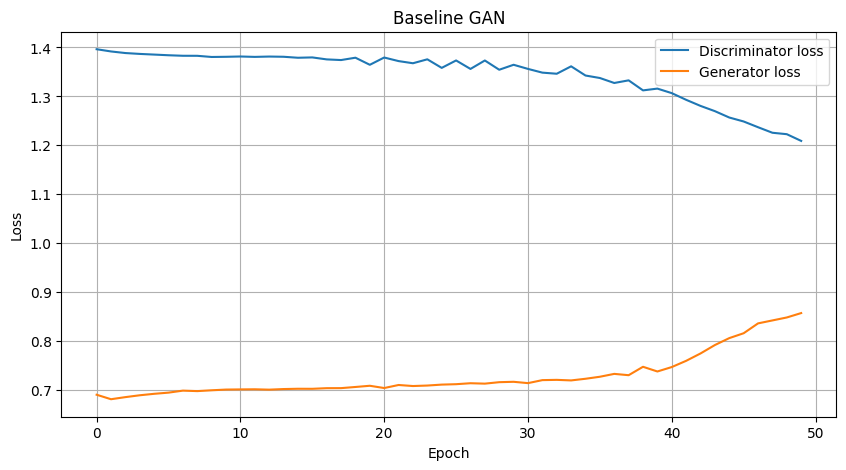

<Figure size 640x480 with 0 Axes>

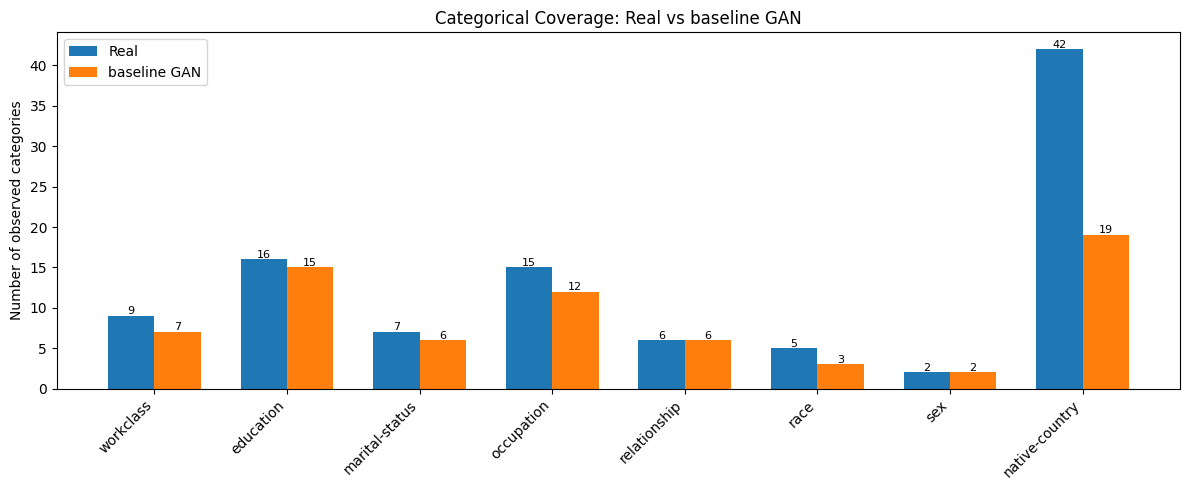

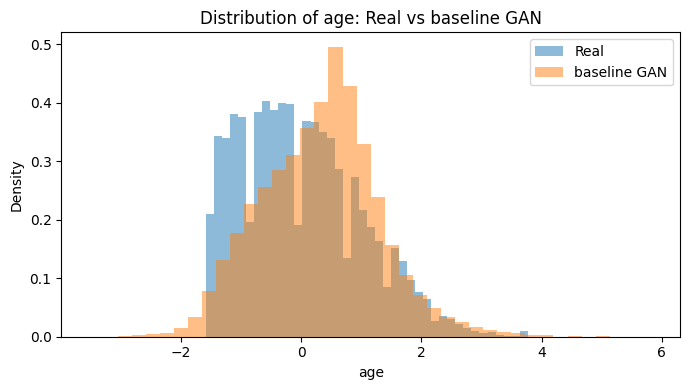

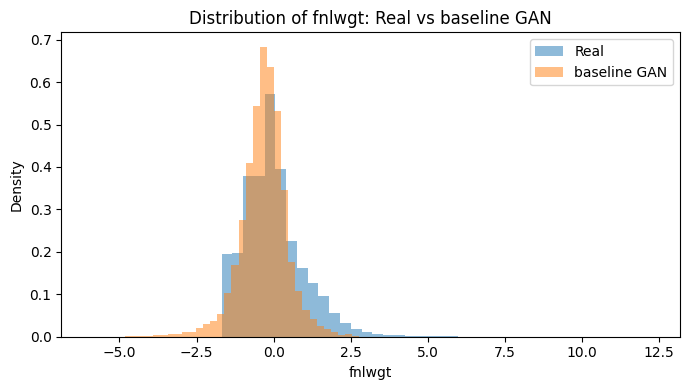

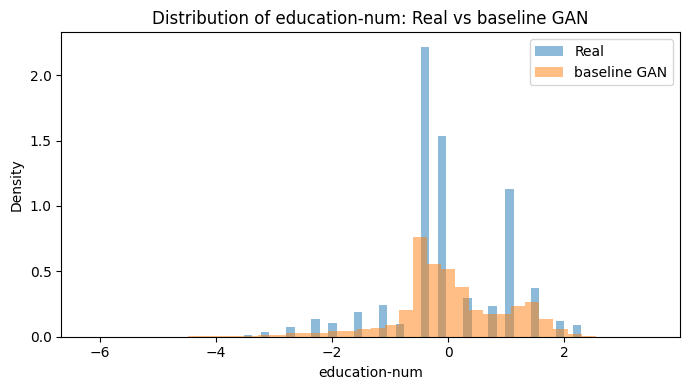

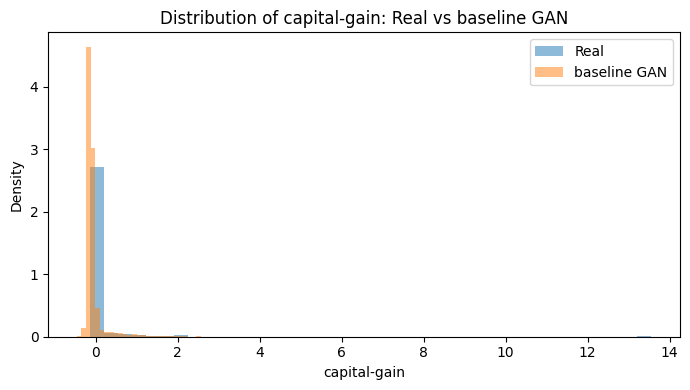

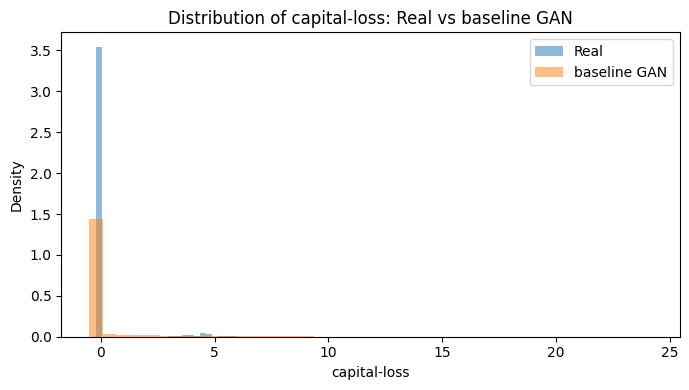

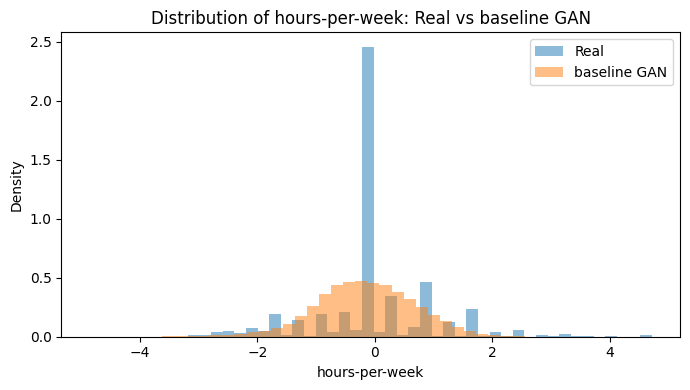

baseline GAN correlation MAE: 0.1276
Detection AUCs: [1.0, 1.0, 1.0, 1.0]
Mean Detection AUC: 1.0
Epoch [10/50] D_loss: 1.3590 G_loss: 0.7573
Epoch [20/50] D_loss: 1.3308 G_loss: 0.7305
Epoch [30/50] D_loss: 1.2831 G_loss: 0.8054
Epoch [40/50] D_loss: 1.3194 G_loss: 0.7734
Epoch [50/50] D_loss: 1.2736 G_loss: 0.8220


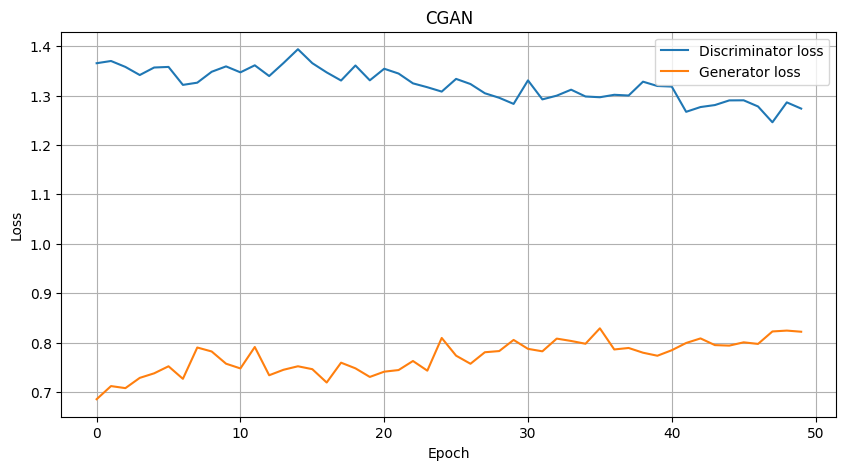

<Figure size 640x480 with 0 Axes>

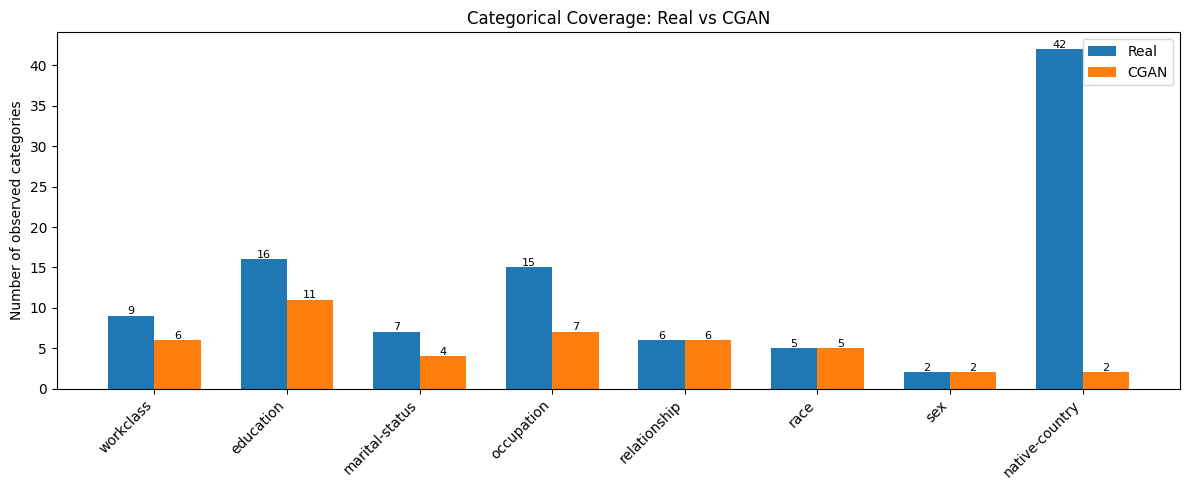

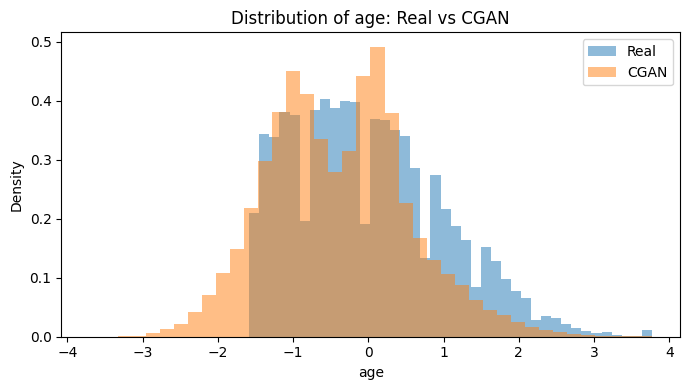

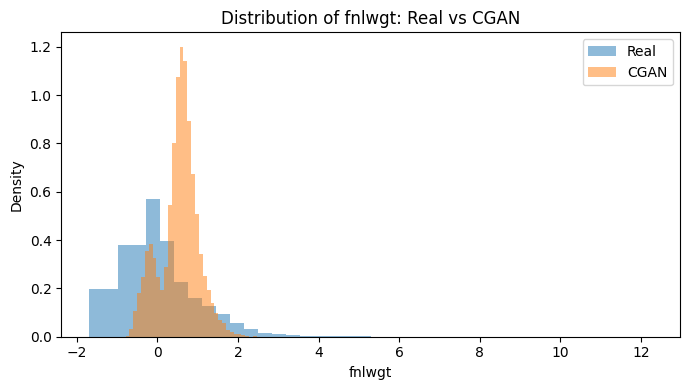

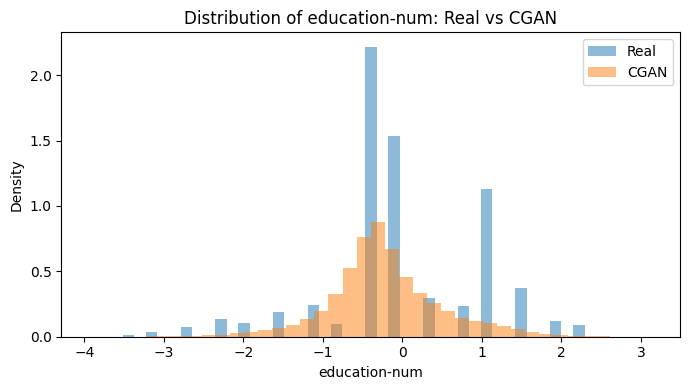

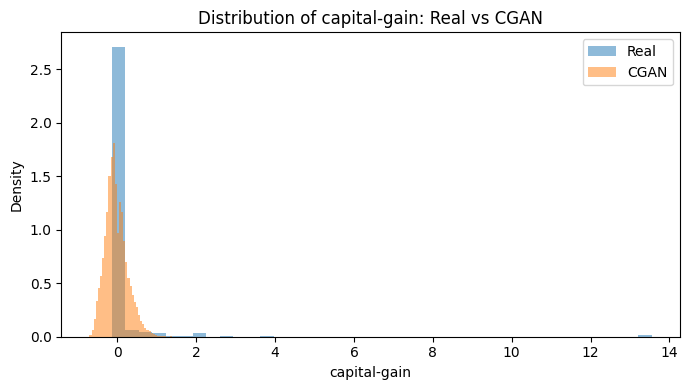

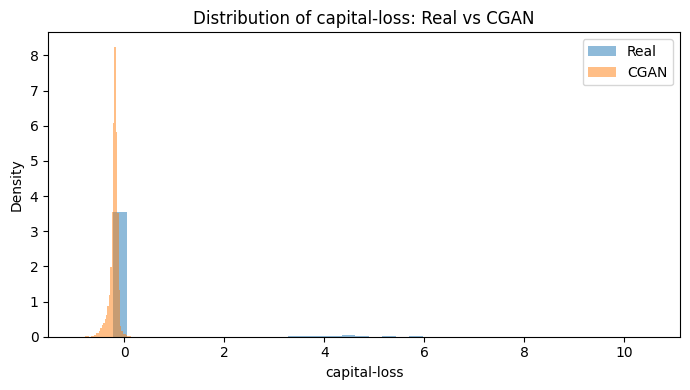

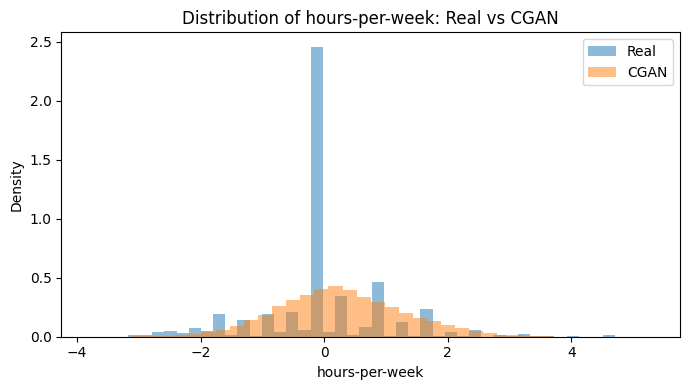

CGAN correlation MAE: 0.2348
Detection AUCs: [1.0, 1.0, 1.0, 1.0]
Mean Detection AUC: 1.0

Running split seed 67
Epoch [10/50] D_loss: 1.3786 G_loss: 0.7019
Epoch [20/50] D_loss: 1.3664 G_loss: 0.7085
Epoch [30/50] D_loss: 1.3370 G_loss: 0.7254
Epoch [40/50] D_loss: 1.2841 G_loss: 0.7822
Epoch [50/50] D_loss: 1.1441 G_loss: 0.9060


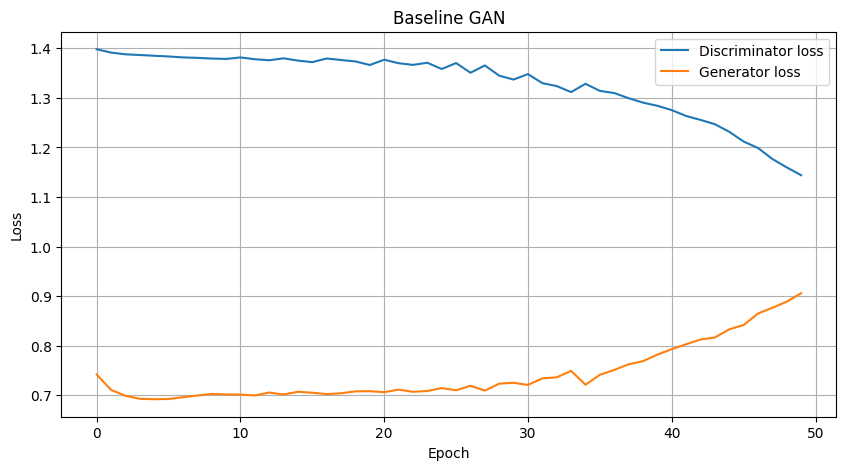

<Figure size 640x480 with 0 Axes>

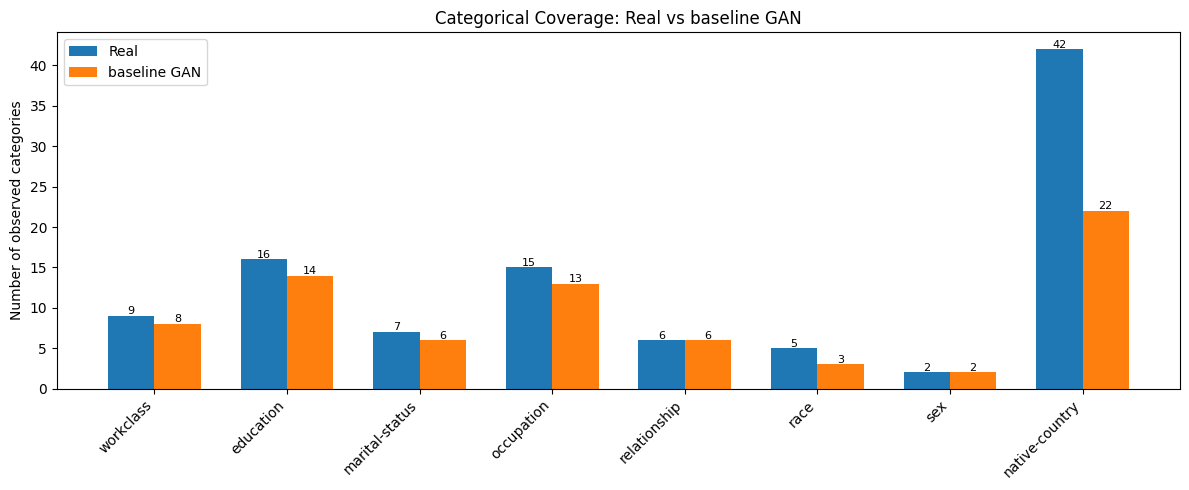

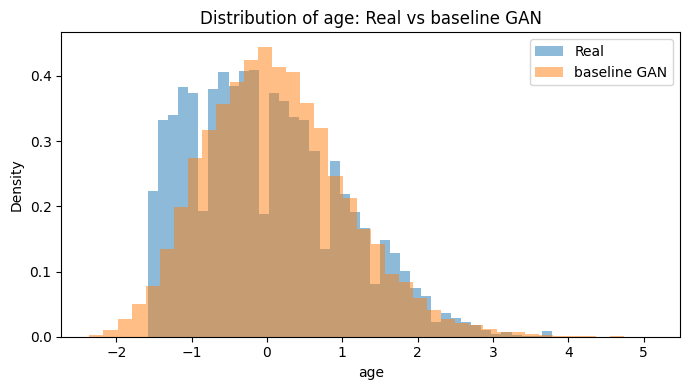

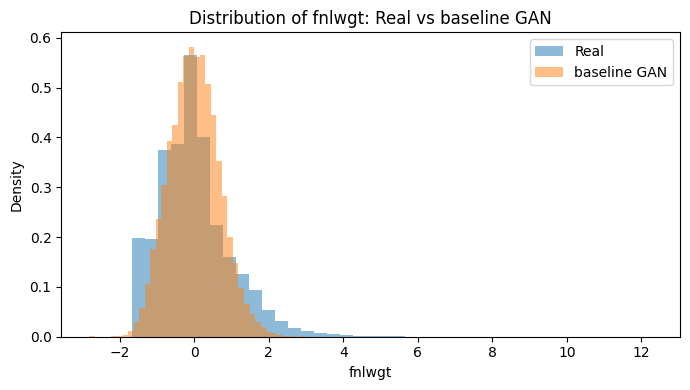

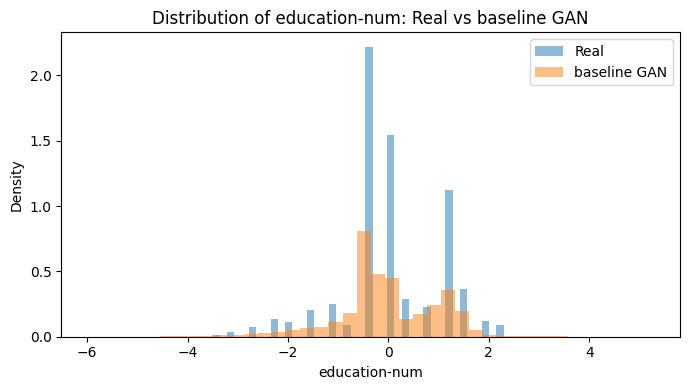

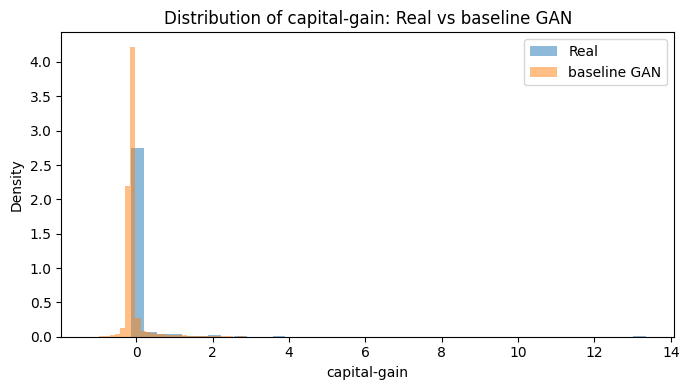

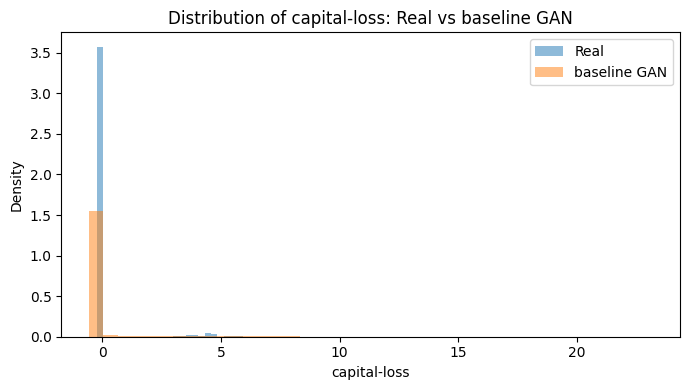

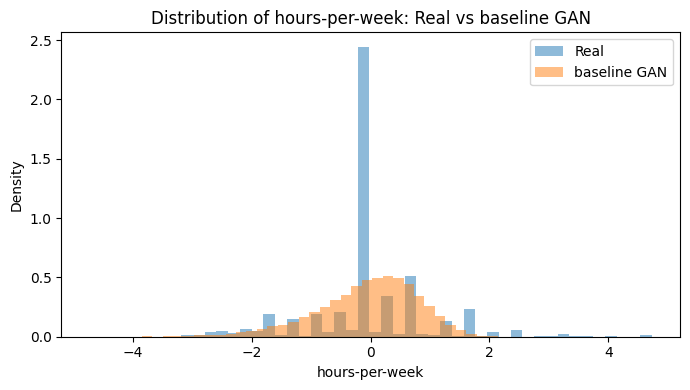

baseline GAN correlation MAE: 0.1208
Detection AUCs: [1.0, 1.0, 1.0, 1.0]
Mean Detection AUC: 1.0
Epoch [10/50] D_loss: 1.3749 G_loss: 0.7240
Epoch [20/50] D_loss: 1.3265 G_loss: 0.7611
Epoch [30/50] D_loss: 1.3087 G_loss: 0.7821
Epoch [40/50] D_loss: 1.3293 G_loss: 0.7793
Epoch [50/50] D_loss: 1.3150 G_loss: 0.7800


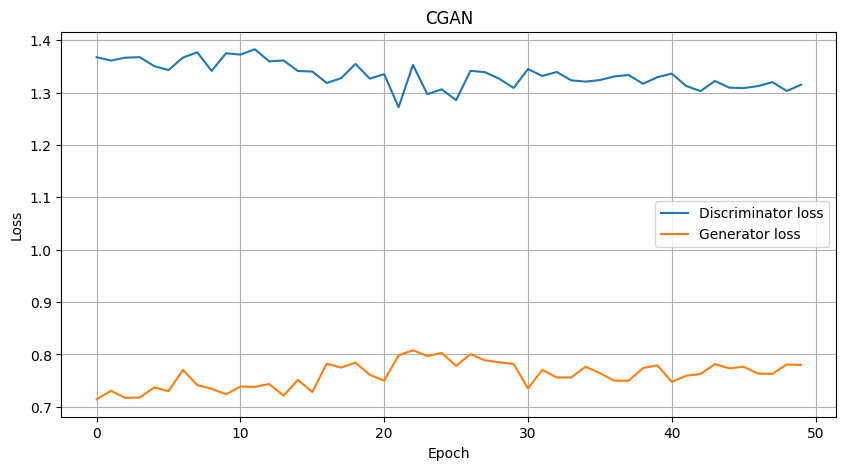

<Figure size 640x480 with 0 Axes>

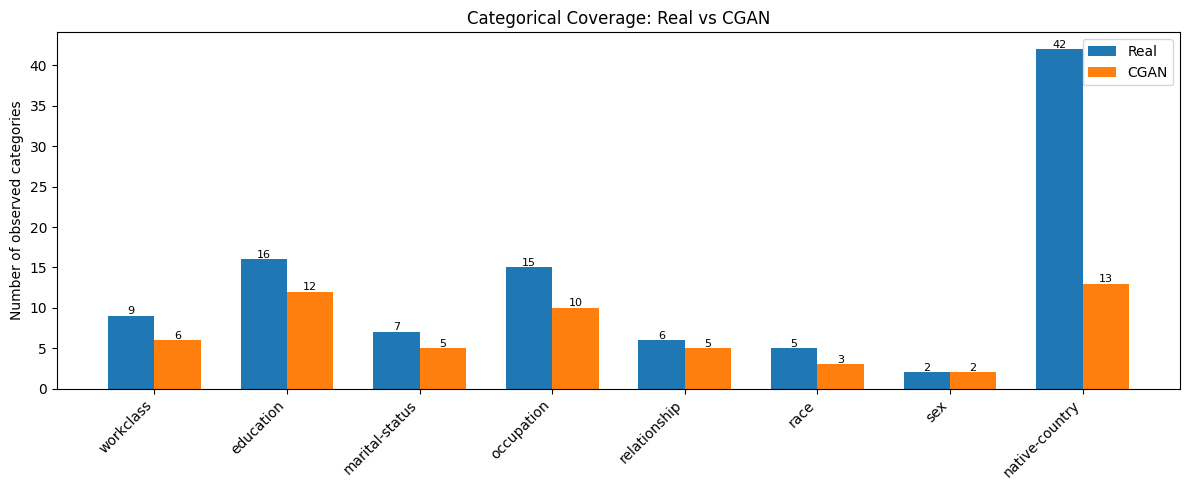

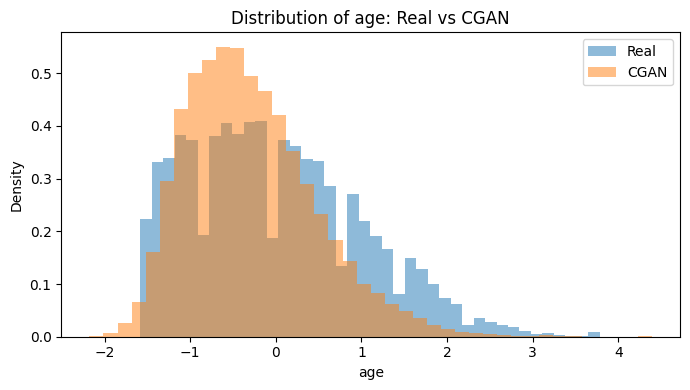

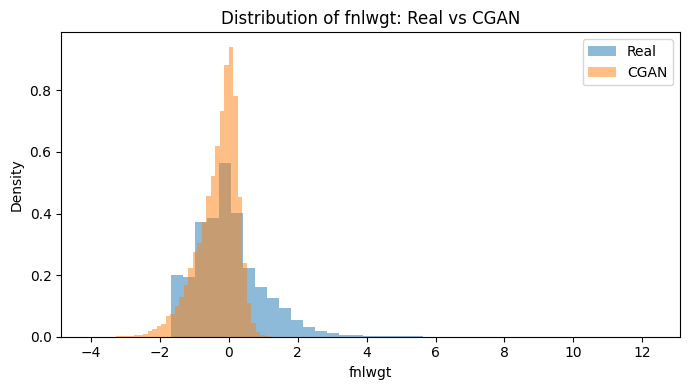

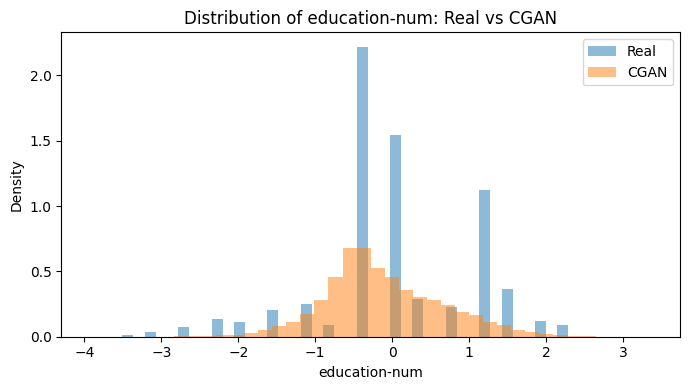

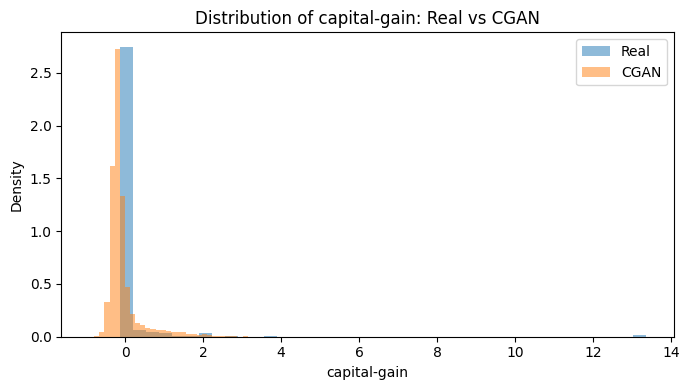

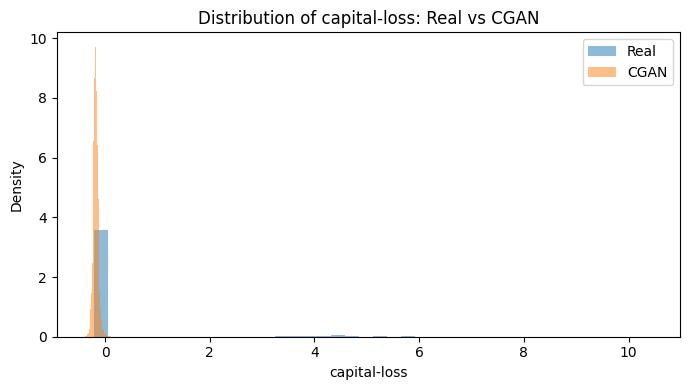

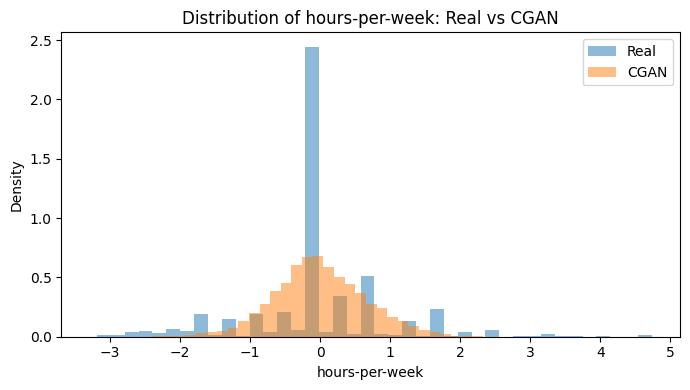

CGAN correlation MAE: 0.2286
Detection AUCs: [1.0, 1.0, 1.0, 1.0]
Mean Detection AUC: 1.0

Running split seed 324
Epoch [10/50] D_loss: 1.3785 G_loss: 0.7061
Epoch [20/50] D_loss: 1.3665 G_loss: 0.7061
Epoch [30/50] D_loss: 1.3564 G_loss: 0.7225
Epoch [40/50] D_loss: 1.3058 G_loss: 0.7443
Epoch [50/50] D_loss: 1.2136 G_loss: 0.8435


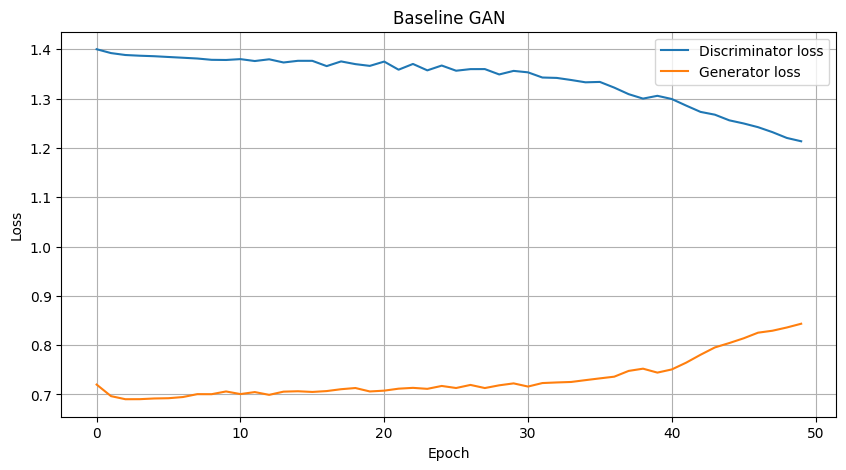

<Figure size 640x480 with 0 Axes>

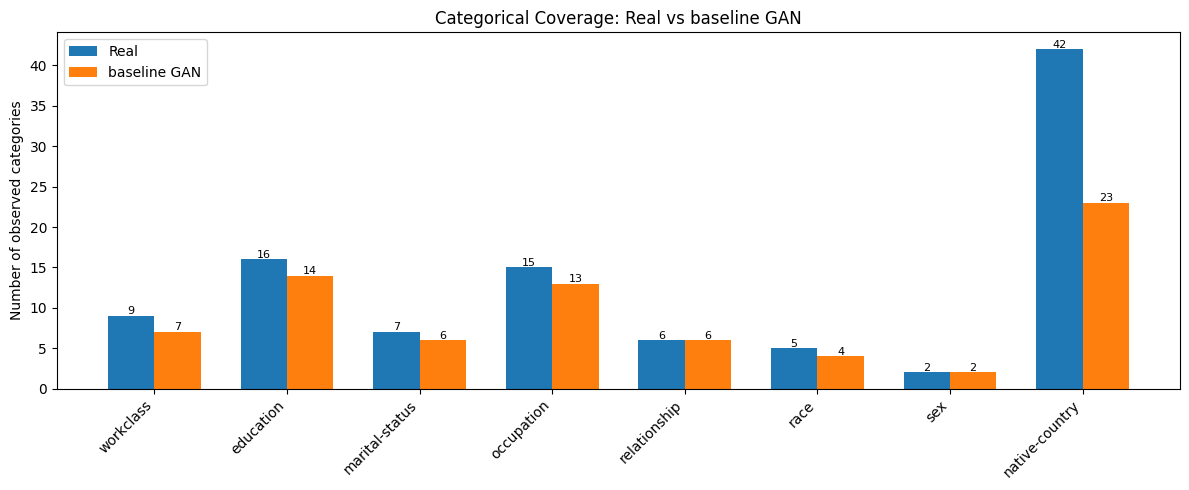

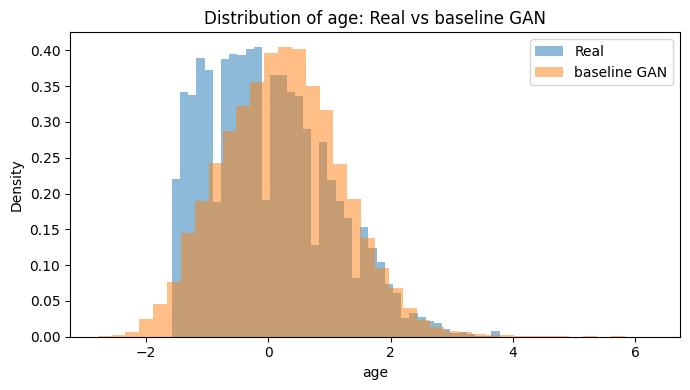

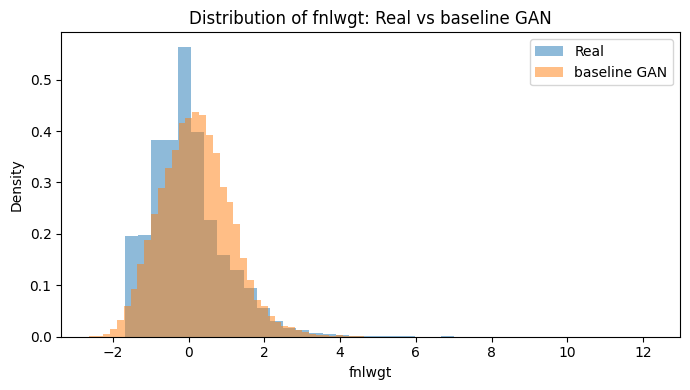

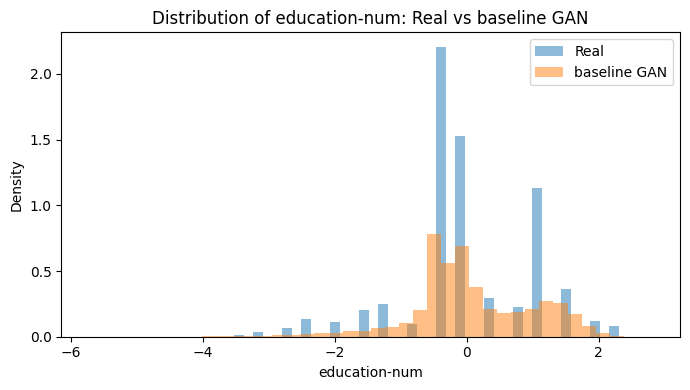

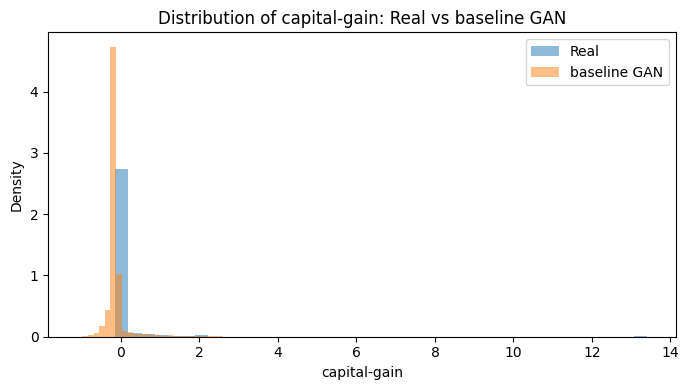

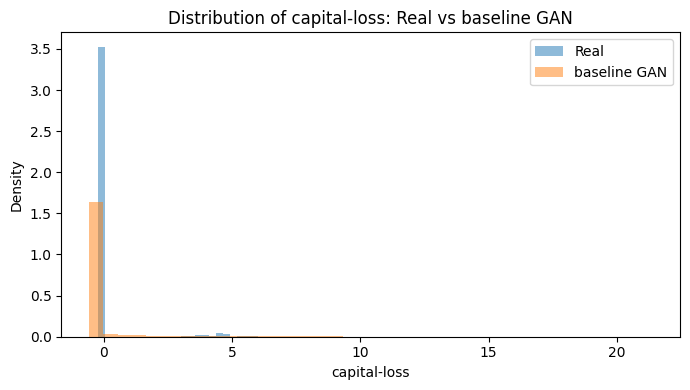

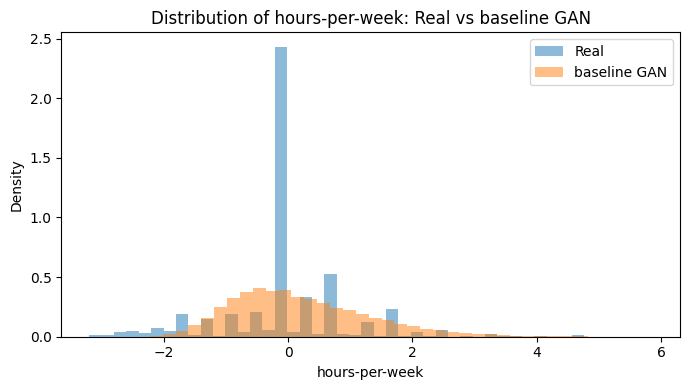

baseline GAN correlation MAE: 0.1100
Detection AUCs: [1.0, 1.0, 1.0, 1.0]
Mean Detection AUC: 1.0
Epoch [10/50] D_loss: 1.3594 G_loss: 0.7554
Epoch [20/50] D_loss: 1.3451 G_loss: 0.7702
Epoch [30/50] D_loss: 1.3586 G_loss: 0.7513
Epoch [40/50] D_loss: 1.3245 G_loss: 0.7750
Epoch [50/50] D_loss: 1.3035 G_loss: 0.7785


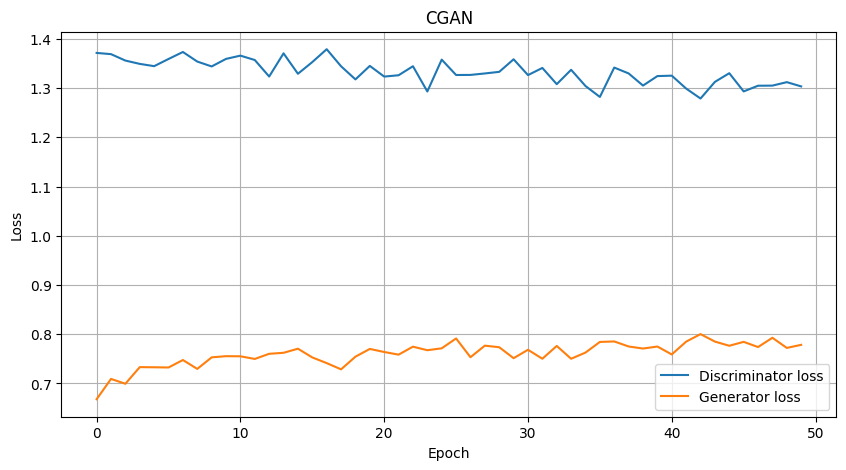

<Figure size 640x480 with 0 Axes>

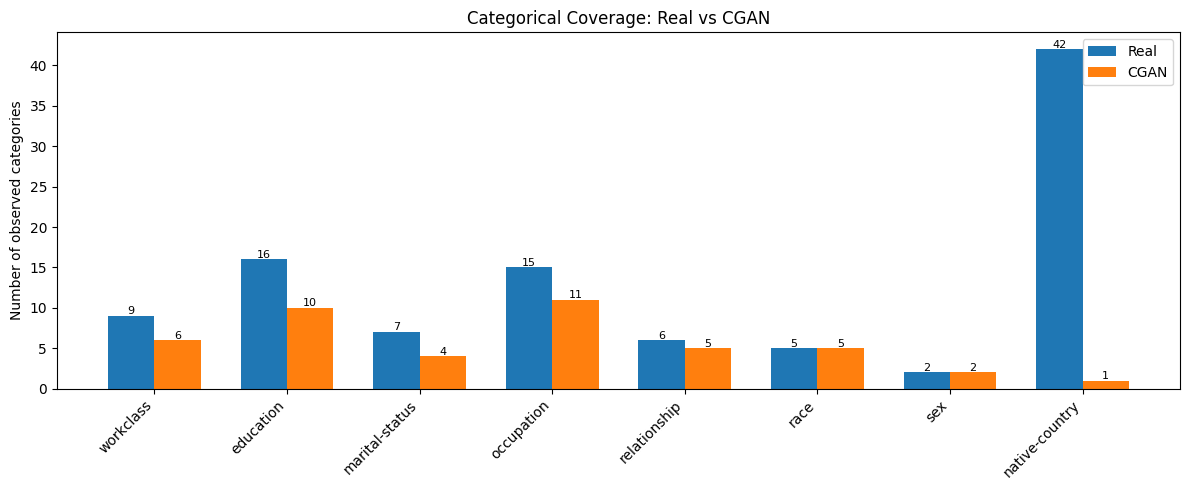

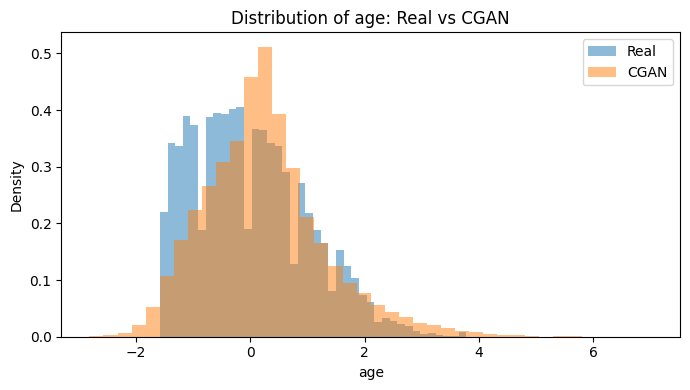

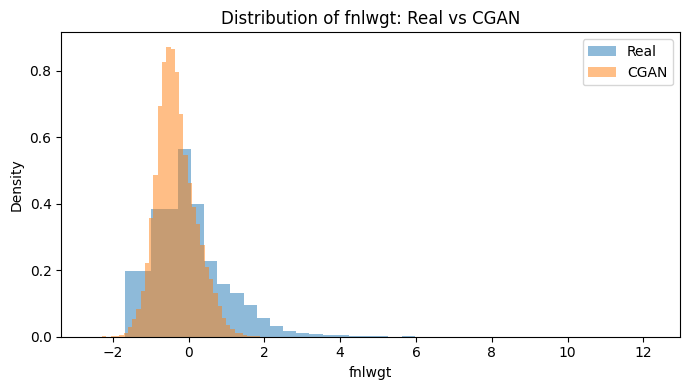

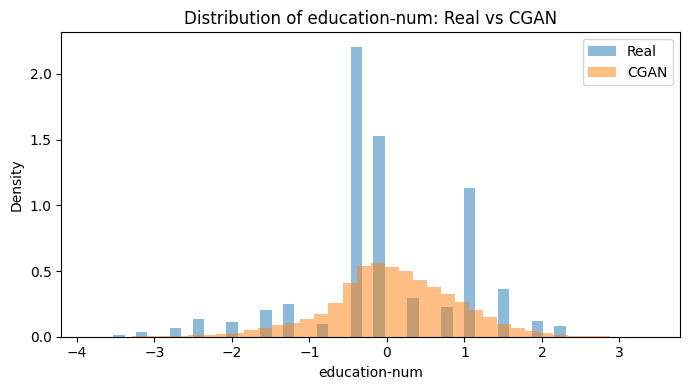

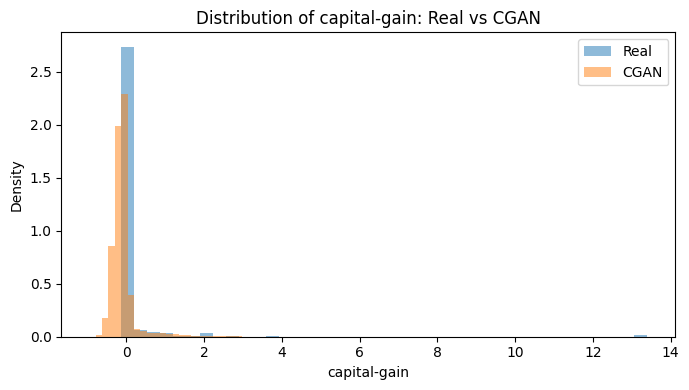

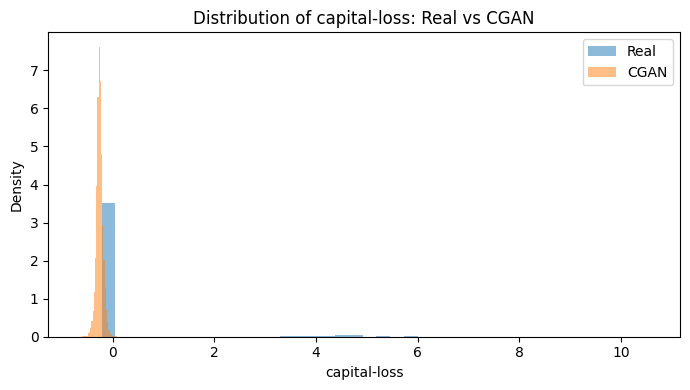

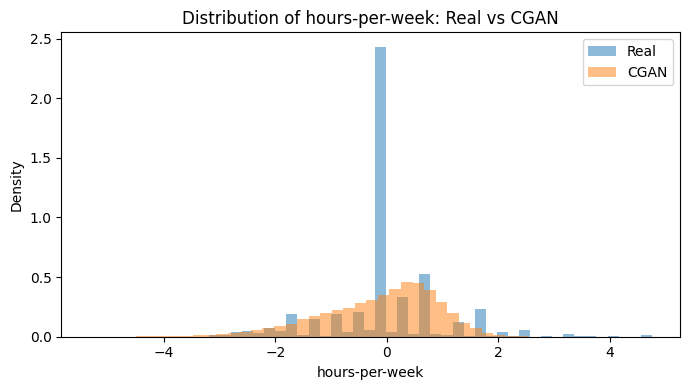

CGAN correlation MAE: 0.1951
Detection AUCs: [1.0, 1.0, 1.0, 1.0]
Mean Detection AUC: 1.0


,seed,gan_detection_auc,gan_auc_real,gan_auc_synth,gan_efficacy,cgan_detection_auc,cgan_auc_real,cgan_auc_synth,cgan_efficacy
0,42,"([1.0, 1.0, 1.0, 1.0], 1.0)",0.907963,0.532597,0.586584,"([1.0, 1.0, 1.0, 1.0], 1.0)",0.907963,0.821467,0.904736
1,67,"([1.0, 1.0, 1.0, 1.0], 1.0)",0.901352,0.610871,0.677727,"([1.0, 1.0, 1.0, 1.0], 1.0)",0.901352,0.688078,0.763384
2,324,"([1.0, 1.0, 1.0, 1.0], 1.0)",0.900891,0.498556,0.553403,"([1.0, 1.0, 1.0, 1.0], 1.0)",0.900891,0.835959,0.927925


seed              144.333333
gan_auc_real        0.903402
gan_auc_synth       0.547341
gan_efficacy        0.605905
cgan_auc_real       0.903402
cgan_auc_synth      0.781835
cgan_efficacy       0.865348
dtype: float64

seed              156.097192
gan_auc_real        0.003957
gan_auc_synth       0.057591
gan_efficacy        0.064375
cgan_auc_real       0.003957
cgan_auc_synth      0.081519
cgan_efficacy       0.089061
dtype: float64

In [ ]:
SEEDS = [42, 67, 324]

all_results = []

for seed in SEEDS:
    print(f"\nRunning split seed {seed}")

    X_train_raw, X_test_raw, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        stratify=y,
        random_state=seed
    )

    X_train = preprocessor.fit_transform(X_train_raw)
    X_test = preprocessor.transform(X_test_raw)

    encoder = preprocessor.named_transformers_["cat"]
    feature_names = (
            continuous_cols
            + list(
                preprocessor.named_transformers_["cat"]
                .get_feature_names_out(categorical_cols)
            )
        )
    ohe = preprocessor.named_transformers_["cat"]
    cat_dims = [
        len(categories)
        for categories in ohe.categories_
    ]


    input_dim = X_train.shape[1]

    result = run_full_pipeline(
        X_train=X_train,
        X_test=X_test,
        y_train=y_train.to_numpy(),
        y_test=y_test.to_numpy(),
        seed=seed,
        device=device,
        input_dim=input_dim,
        save_path="results"
    )

    all_results.append(result)

results_df = pd.DataFrame(all_results)
display(results_df)
display(results_df.mean(numeric_only=True))
display(results_df.std(numeric_only=True))

# Gumble Softmax

In [35]:
def train_mode_gan(
    train_loader,
    input_dim,
    noise_dim,
    device,
    num_epochs=50,
    lr_g=2e-4,
    lr_d=1e-4,
    label_smoothing=False,
    cat_mode="raw",
    cat_dims=None,
    n_cont=None,
    tau=1.0
):
    G = Generator(noise_dim, input_dim).to(device)
    D = Discriminator(input_dim).to(device)

    criterion = nn.BCEWithLogitsLoss()

    optimizer_G = torch.optim.Adam(G.parameters(), lr=lr_g, betas=(0.5, 0.999))
    optimizer_D = torch.optim.Adam(D.parameters(), lr=lr_d, betas=(0.5, 0.999))

    G_losses = []
    D_losses = []

    def apply_categorical_mode(x):
        if cat_mode == "raw":
            return x

        cont = x[:, :n_cont]
        cat_logits = x[:, n_cont:]

        parts = []
        start = 0

        for dim in cat_dims:
            logits = cat_logits[:, start:start + dim]

            if cat_mode == "softmax":
                out = torch.softmax(logits, dim=1)

            elif cat_mode == "gumbel":
                out = torch.nn.functional.gumbel_softmax(
                    logits,
                    tau=tau,
                    hard=True,
                    dim=1
                )

            else:
                raise ValueError(f"Unknown cat_mode: {cat_mode}")

            parts.append(out)
            start += dim

        return torch.cat([cont] + parts, dim=1)

    for epoch in range(num_epochs):
        epoch_G_loss = 0.0
        epoch_D_loss = 0.0

        for (real_batch,) in train_loader:
            real_batch = real_batch.to(device)
            batch_size = real_batch.size(0)

            if label_smoothing:
                real_labels = torch.empty(batch_size, 1, device=device).uniform_(0.8, 1.0)
                fake_labels = torch.empty(batch_size, 1, device=device).uniform_(0.0, 0.1)
            else:
                real_labels = torch.ones(batch_size, 1, device=device)
                fake_labels = torch.zeros(batch_size, 1, device=device)

            # -----------------
            # Train Discriminator
            # -----------------
            z = torch.randn(batch_size, noise_dim, device=device)

            fake_batch = G(z)
            fake_batch = apply_categorical_mode(fake_batch).detach()

            D_real = D(real_batch)
            D_fake = D(fake_batch)

            D_loss_real = criterion(D_real, real_labels)
            D_loss_fake = criterion(D_fake, fake_labels)
            D_loss = D_loss_real + D_loss_fake

            optimizer_D.zero_grad()
            D_loss.backward()
            optimizer_D.step()

            # -----------------
            # Train Generator
            # -----------------
            z = torch.randn(batch_size, noise_dim, device=device)

            fake_batch = G(z)
            fake_batch = apply_categorical_mode(fake_batch)

            D_fake = D(fake_batch)
            G_loss = criterion(D_fake, real_labels)

            optimizer_G.zero_grad()
            G_loss.backward()
            optimizer_G.step()

            epoch_D_loss += D_loss.item()
            epoch_G_loss += G_loss.item()

        epoch_D_loss /= len(train_loader)
        epoch_G_loss /= len(train_loader)

        D_losses.append(epoch_D_loss)
        G_losses.append(epoch_G_loss)

        if (epoch + 1) % 10 == 0:
            print(
                f"[{cat_mode}] Epoch [{epoch+1}/{num_epochs}] "
                f"D_loss: {epoch_D_loss:.4f} "
                f"G_loss: {epoch_G_loss:.4f}"
            )

    return G, D, G_losses, D_losses

In [35]:
X_train_tensor = torch.tensor(
    X_train,
    dtype=torch.float32
)
train_dataset = TensorDataset(X_train_tensor)
train_loader = DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True
)
noise_dim = 32
input_dim = X_train.shape[1]
ohe = preprocessor.named_transformers_["cat"]
cat_dims = [
    len(categories)
    for categories in ohe.categories_
]
n_cont = len(continuous_cols)

print("input_dim =", X_train.shape[1])
print("noise_dim =", noise_dim)
print("n_cont =", n_cont)
print("cat_dims =", cat_dims)

input_dim = 108
noise_dim = 32
n_cont = 6
cat_dims = [9, 16, 7, 15, 6, 5, 2, 42]


In [233]:
assert n_cont + sum(cat_dims) == X_train.shape[1]

In [235]:
G_soft, D_soft, G_losses_soft, D_losses_soft = train_mode_gan(
    train_loader=train_loader,
    input_dim=input_dim,
    noise_dim=noise_dim,
    device=device,
    num_epochs=50,
    cat_mode="softmax",
    cat_dims=cat_dims,
    n_cont=n_cont,
    tau=1.0
)

[softmax] Epoch [10/50] D_loss: 1.0886 G_loss: 1.1634
[softmax] Epoch [20/50] D_loss: 0.8712 G_loss: 1.3158
[softmax] Epoch [30/50] D_loss: 0.7285 G_loss: 1.5029
[softmax] Epoch [40/50] D_loss: 0.6446 G_loss: 1.7318
[softmax] Epoch [50/50] D_loss: 0.6076 G_loss: 1.8725


In [237]:
G_gumbel, D_gumbel, G_losses_gumbel, D_losses_gumbel = train_mode_gan(
    train_loader=train_loader,
    input_dim=input_dim,
    noise_dim=noise_dim,
    device=device,
    num_epochs=50,
    cat_mode="gumbel",
    cat_dims=cat_dims,
    n_cont=n_cont,
    tau=1.0
)

[gumbel] Epoch [10/50] D_loss: 1.3515 G_loss: 0.7099
[gumbel] Epoch [20/50] D_loss: 1.2394 G_loss: 0.8189
[gumbel] Epoch [30/50] D_loss: 1.0790 G_loss: 1.0047
[gumbel] Epoch [40/50] D_loss: 0.8313 G_loss: 1.6211
[gumbel] Epoch [50/50] D_loss: 0.6623 G_loss: 2.5368


In [238]:
assert n_cont + sum(cat_dims) == X_train.shape[1]

In [ ]:
def generate_synthetic_with_cat_mode(
    G,
    n_samples,
    noise_dim,
    device,
    cat_mode,
    cat_dims,
    n_cont,
    tau=1.0,
    batch_size=128
):
    G.eval()
    synth_batches = []

    with torch.no_grad():
        for start in range(0, n_samples, batch_size):
            curr_bs = min(batch_size, n_samples - start)

            z = torch.randn(curr_bs, noise_dim, device=device)
            raw = G(z)

            cont = raw[:, :n_cont]
            cat_logits = raw[:, n_cont:]

            cat_parts = []
            pos = 0

            for dim in cat_dims:
                logits = cat_logits[:, pos:pos + dim]

                if cat_mode == "softmax":
                    out = torch.softmax(logits, dim=1)

                elif cat_mode == "gumbel":
                    out = torch.nn.functional.gumbel_softmax(
                        logits,
                        tau=tau,
                        hard=True,
                        dim=1
                    )

                else:
                    raise ValueError(cat_mode)

                cat_parts.append(out)
                pos += dim

            fake = torch.cat([cont] + cat_parts, dim=1)
            synth_batches.append(fake.cpu().numpy())

    return np.vstack(synth_batches)

In [249]:
X_soft = generate_synthetic_with_cat_mode(
    G_soft,
    n_samples=len(X_train),
    noise_dim=noise_dim,
    device=device,
    cat_mode="softmax",
    cat_dims=cat_dims,
    n_cont=n_cont,
    tau=1.0
)

X_gumbel = generate_synthetic_with_cat_mode(
    G_gumbel,
    n_samples=len(X_train),
    noise_dim=noise_dim,
    device=device,
    cat_mode="gumbel",
    cat_dims=cat_dims,
    n_cont=n_cont,
    tau=0.5
)

X_soft_oh = postprocess_synthetic_tabular(
    X_soft,
    n_cont=n_cont,
    cat_dims=cat_dims
)

X_gumbel_oh = postprocess_synthetic_tabular(
    X_gumbel,
    n_cont=n_cont,
    cat_dims=cat_dims
)

soft_detection_auc = run_detection_auc(X_train, X_soft_oh)
gumbel_detection_auc = run_detection_auc(X_train, X_gumbel_oh)

print("Softmax Detection AUC:", soft_detection_auc)
print("Gumbel Detection AUC:", gumbel_detection_auc)

Detection AUCs: [1.0, 1.0, 1.0, 1.0]
Mean Detection AUC: 1.0
Detection AUCs: [0.9999999646277672, 1.0, 1.0, 1.0]
Mean Detection AUC: 0.9999999911569418
Softmax Detection AUC: ([1.0, 1.0, 1.0, 1.0], np.float64(1.0))
Gumbel Detection AUC: ([0.9999999646277672, 1.0, 1.0, 1.0], np.float64(0.9999999911569418))


In [37]:
def entropy(p, eps=1e-12):
    p = np.clip(p, eps, 1.0)
    return -np.sum(p * np.log(p), axis=1)


def categorical_entropy_report(
    X_real,
    X_soft,
    X_gumbel,
    cat_cols,
    cat_dims,
    n_cont
):
    rows = []

    start = n_cont

    for col, dim in zip(cat_cols, cat_dims):
        end = start + dim

        real_block = X_real[:, start:end]
        soft_block = X_soft[:, start:end]
        gumbel_block = X_gumbel[:, start:end]

        real_freq = real_block.mean(axis=0)
        soft_probs = soft_block
        gumbel_probs = gumbel_block

        real_entropy = -np.sum(
            np.clip(real_freq, 1e-12, 1.0) *
            np.log(np.clip(real_freq, 1e-12, 1.0))
        )

        soft_entropy = entropy(soft_probs).mean()
        gumbel_entropy = entropy(gumbel_probs).mean()

        rows.append({
            "feature": col,
            "real_entropy": real_entropy,
            "softmax_entropy": soft_entropy,
            "gumbel_entropy": gumbel_entropy
        })

        start = end

    return pd.DataFrame(rows)

In [251]:
entropy_df = categorical_entropy_report(
    X_real=X_train,
    X_soft=X_soft,
    X_gumbel=X_gumbel,
    cat_cols=categorical_cols,
    cat_dims=cat_dims,
    n_cont=n_cont
)
display(entropy_df)

,feature,real_entropy,softmax_entropy,gumbel_entropy
0,workclass,1.139193,0.036565,2.210481e-10
1,education,2.034104,0.078970,4.144653e-10
2,marital-status,1.269382,0.046640,1.657861e-10
3,occupation,2.437632,0.104912,3.868342e-10
4,relationship,1.492807,0.048354,1.381551e-10
5,race,0.555522,0.025371,1.105241e-10
6,sex,0.633145,0.019484,2.763102e-11
7,native-country,0.654730,0.000486,1.132872e-09


In [39]:
def category_coverage_report(
    X_real,
    X_synth,
    cat_cols,
    cat_dims,
    n_cont,
    model_name
):
    rows = []

    start = n_cont

    for col, dim in zip(cat_cols, cat_dims):
        end = start + dim

        real_cat = X_real[:, start:end].argmax(axis=1)
        synth_cat = X_synth[:, start:end].argmax(axis=1)

        real_unique = len(np.unique(real_cat))
        synth_unique = len(np.unique(synth_cat))

        rows.append({
            "model": model_name,
            "feature": col,
            "real_unique": real_unique,
            "synth_unique": synth_unique,
            "coverage_ratio": synth_unique / real_unique
        })

        start = end

    return pd.DataFrame(rows)

In [258]:
coverage_soft = category_coverage_report(
    X_train,
    X_soft,
    categorical_cols,
    cat_dims,
    n_cont,
    "softmax"
)

coverage_gumbel = category_coverage_report(
    X_train,
    X_gumbel,
    categorical_cols,
    cat_dims,
    n_cont,
    "gumbel"
)

coverage_df = pd.concat(
    [coverage_soft, coverage_gumbel],
    ignore_index=True
)

display(coverage_df)

,model,feature,real_unique,synth_unique,coverage_ratio
0,softmax,workclass,9,6,0.666667
1,softmax,education,16,10,0.625000
2,softmax,marital-status,7,6,0.857143
3,softmax,occupation,15,12,0.800000
4,softmax,relationship,6,6,1.000000
5,softmax,race,5,4,0.800000
6,softmax,sex,2,2,1.000000
7,softmax,native-country,42,1,0.023810
8,gumbel,workclass,9,9,1.000000
9,gumbel,education,16,16,1.000000


In [259]:
summary_df = pd.DataFrame([
    {
        "model": "softmax",
        "detection_auc": soft_detection_auc,
        "mean_entropy": entropy_df["softmax_entropy"].mean(),
        "mean_coverage": coverage_soft["coverage_ratio"].mean()
    },
    {
        "model": "gumbel",
        "detection_auc": gumbel_detection_auc,
        "mean_entropy": entropy_df["gumbel_entropy"].mean(),
        "mean_coverage": coverage_gumbel["coverage_ratio"].mean()
    }
])

display(summary_df)

,model,detection_auc,mean_entropy,mean_coverage
0,softmax,"([1.0, 1.0, 1.0, 1.0], 1.0)",4.509746e-02,0.721577
1,gumbel,"([0.9999999646277672, 1.0, 1.0, 1.0], 0.999999...",3.246645e-10,0.892857


# Section 8 - Mode collapse

In [32]:
def train_gan_unfair_updates(
    G,
    D,
    train_loader,
    noise_dim,
    device,
    num_epochs=50,
    d_updates=3,
    g_updates=1,
    lr_g=2e-4,
    lr_d=1e-4,
    lambda_fm=0.0,
):
    criterion = nn.BCEWithLogitsLoss()

    opt_G = torch.optim.Adam(G.parameters(), lr=lr_g, betas=(0.5, 0.999))
    opt_D = torch.optim.Adam(D.parameters(), lr=lr_d, betas=(0.5, 0.999))

    G_losses = []
    D_losses = []

    for epoch in range(num_epochs):
        epoch_G_loss = 0
        epoch_D_loss = 0
        n_batches = 0

        for real_batch, in train_loader:
            real_batch = real_batch.to(device).float()
            curr_bs = real_batch.size(0)

            # -------------------------
            # Train Discriminator more
            # -------------------------
            for _ in range(d_updates):
                z = torch.randn(curr_bs, noise_dim, device=device)
                fake_batch = G(z).detach()

                real_labels = torch.ones(curr_bs, 1, device=device)
                fake_labels = torch.zeros(curr_bs, 1, device=device)

                D_real = D(real_batch)
                D_fake = D(fake_batch)

                D_loss_real = criterion(D_real, real_labels)
                D_loss_fake = criterion(D_fake, fake_labels)

                D_loss = D_loss_real + D_loss_fake

                opt_D.zero_grad()
                D_loss.backward()
                opt_D.step()

            # -------------------------
            # Train Generator less
            # -------------------------
            for _ in range(g_updates):
                z = torch.randn(curr_bs, noise_dim, device=device)
                fake_batch = G(z)

                target_labels = torch.ones(curr_bs, 1, device=device)

                D_fake, fake_features = D(fake_batch, return_features=True)

                with torch.no_grad():
                    _, real_features = D(real_batch, return_features=True)

                adv_loss = criterion(D_fake, target_labels)

                fm_loss = torch.mean(
                    (real_features.mean(dim=0) - fake_features.mean(dim=0)) ** 2
                )

                G_loss = adv_loss + lambda_fm * fm_loss

                opt_G.zero_grad()
                G_loss.backward()
                opt_G.step()

            epoch_D_loss += D_loss.item()
            epoch_G_loss += G_loss.item()
            n_batches += 1

        G_losses.append(epoch_G_loss / n_batches)
        D_losses.append(epoch_D_loss / n_batches)

        if (epoch + 1) % 10 == 0:
            print(
                f"Epoch [{epoch+1}/{num_epochs}] "
                f"D Loss: {D_losses[-1]:.4f} | "
                f"G Loss: {G_losses[-1]:.4f}"
            )

    return G, D, G_losses, D_losses

In [33]:
torch.cuda.empty_cache()

In [36]:
G_unfair, D_unfair, G_losses_unfair, D_losses_unfair = train_gan_unfair_updates(
    G=Generator(noise_dim, input_dim).to(device),
    D=Discriminator(input_dim).to(device),
    train_loader=train_loader,
    noise_dim=noise_dim,
    device=device,
    num_epochs=50,
    d_updates=5,
    g_updates=1,
)

Epoch [10/50] D Loss: 0.3164 | G Loss: 2.6363
Epoch [20/50] D Loss: 0.0236 | G Loss: 6.0158
Epoch [30/50] D Loss: 0.0037 | G Loss: 8.4837
Epoch [40/50] D Loss: 0.0020 | G Loss: 9.6486
Epoch [50/50] D Loss: 0.0011 | G Loss: 10.2545


In [42]:
G_fm, D_fm, G_fm_losses, D_fm_losses = train_gan_unfair_updates(
    G=Generator(noise_dim, input_dim).to(device),
    D=Discriminator(input_dim).to(device),
    train_loader=train_loader,
    noise_dim=noise_dim,
    device=device,
    num_epochs=50,
    d_updates=5,
    g_updates=1,
    lambda_fm=5.0
)

Epoch [10/50] D Loss: 0.2874 | G Loss: 3.0843


KeyboardInterrupt: 

In [40]:
X_bad = generate_synthetic(G_unfair, len(X_train), noise_dim, device)
X_fm = generate_synthetic(G_fm, len(X_train), noise_dim, device)

coverage_bad = category_coverage_report(
    X_train, X_bad, categorical_cols, cat_dims, n_cont, "collapsed_gan"
)

coverage_fm = category_coverage_report(
    X_train, X_fm, categorical_cols, cat_dims, n_cont, "feature_matching_gan"
)

collapse_mitigation_df = pd.concat(
    [coverage_bad, coverage_fm],
    ignore_index=True
)

display(collapse_mitigation_df)

,model,feature,real_unique,synth_unique,coverage_ratio
0,collapsed_gan,workclass,9,5,0.555556
1,collapsed_gan,education,16,12,0.750000
2,collapsed_gan,marital-status,7,5,0.714286
3,collapsed_gan,occupation,15,12,0.800000
4,collapsed_gan,relationship,6,5,0.833333
5,collapsed_gan,race,5,3,0.600000
6,collapsed_gan,sex,2,2,1.000000
7,collapsed_gan,native-country,42,22,0.523810
8,feature_matching_gan,workclass,9,1,0.111111
9,feature_matching_gan,education,16,10,0.625000


In [41]:
collapse_score = (
    collapse_mitigation_df
    .groupby("model")["coverage_ratio"]
    .mean()
    .sort_values(ascending=False)
)

print(collapse_score)

model
collapsed_gan           0.722123
feature_matching_gan    0.626538
Name: coverage_ratio, dtype: float64


# section 9

In [182]:
zero_inflated_cols = ["capital-gain", "capital-loss"]

zi_indices = [
    continuous_cols.index(col)
    for col in zero_inflated_cols
]

zi_indices

[3, 4]

In [187]:
class ZeroInflatedGenerator(nn.Module):
    def __init__(self, noise_dim, output_dim, zi_indices, hidden_dim=256, tau=0.5):
        super().__init__()

        self.output_dim = output_dim
        self.zi_indices = zi_indices
        self.tau = tau

        self.backbone = nn.Sequential(
            nn.Linear(noise_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU()
        )

        # normal output for all features
        self.base_head = nn.Sequential(
            nn.Linear(hidden_dim, output_dim),
            nn.Sigmoid()
        )

        # for each zero-inflated feature: gate and value
        self.gate_heads = nn.ModuleDict()
        self.value_heads = nn.ModuleDict()

        for idx in zi_indices:
            self.gate_heads[str(idx)] = nn.Linear(hidden_dim, 2)   # zero / nonzero
            self.value_heads[str(idx)] = nn.Sequential(
                nn.Linear(hidden_dim, 1),
                nn.Sigmoid()
            )

    def forward(self, z):
        h = self.backbone(z)

        base = self.base_head(h)

        outputs = []

        for j in range(self.output_dim):
            if j in self.zi_indices:
                gate_logits = self.gate_heads[str(j)](h)

                gate = F.gumbel_softmax(
                    gate_logits,
                    tau=self.tau,
                    hard=True,
                    dim=1
                )

                nonzero_gate = gate[:, 1:2]
                value = self.value_heads[str(j)](h)

                out_j = nonzero_gate * value
            else:
                out_j = base[:, j:j+1]

            outputs.append(out_j)

        x = torch.cat(outputs, dim=1)

        return x

In [184]:
def wasserstein_1d_loss(real, fake, feature_indices):
    loss = 0.0

    for idx in feature_indices:
        real_sorted = torch.sort(real[:, idx])[0]
        fake_sorted = torch.sort(fake[:, idx])[0]

        loss += torch.mean(torch.abs(real_sorted - fake_sorted))

    return loss / len(feature_indices)

In [ ]:
def train_zero_inflated_gan(
    train_loader,
    input_dim,
    noise_dim,
    zi_indices,
    device,
    num_epochs=50,
    lr_g=2e-4,
    lr_d=1e-4,
    lambda_w=10.0,
    tau=0.5
):
    G = ZeroInflatedGenerator(
        noise_dim=noise_dim,
        output_dim=input_dim,
        zi_indices=zi_indices,
        tau=tau
    ).to(device)

    D = Discriminator(input_dim).to(device)

    criterion = nn.BCELoss()

    opt_G = torch.optim.Adam(G.parameters(), lr=lr_g, betas=(0.5, 0.999))
    opt_D = torch.optim.Adam(D.parameters(), lr=lr_d, betas=(0.5, 0.999))

    G_losses = []
    D_losses = []

    for epoch in range(num_epochs):
        epoch_G_loss = 0
        epoch_D_loss = 0
        n_batches = 0

        for real_batch, in train_loader:
            real_batch = real_batch.to(device).float()
            curr_bs = real_batch.size(0)

            real_labels = torch.ones(curr_bs, 1, device=device)
            fake_labels = torch.zeros(curr_bs, 1, device=device)

            # ------------------
            # Train D
            # ------------------
            z = torch.randn(curr_bs, noise_dim, device=device)
            fake_batch = G(z).detach()

            D_real = D(real_batch)
            D_fake = D(fake_batch)

            D_loss = (
                criterion(D_real, real_labels)
                + criterion(D_fake, fake_labels)
            )

            opt_D.zero_grad()
            D_loss.backward()
            opt_D.step()

            # ------------------
            # Train G
            # ------------------
            z = torch.randn(curr_bs, noise_dim, device=device)
            fake_batch = G(z)

            D_fake = D(fake_batch)

            adv_loss = criterion(D_fake, real_labels)

            w_loss = wasserstein_1d_loss(
                real=real_batch,
                fake=fake_batch,
                feature_indices=zi_indices
            )

            G_loss = adv_loss + lambda_w * w_loss

            opt_G.zero_grad()
            G_loss.backward()
            opt_G.step()

            epoch_D_loss += D_loss.item()
            epoch_G_loss += G_loss.item()
            n_batches += 1

        G_losses.append(epoch_G_loss / n_batches)
        D_losses.append(epoch_D_loss / n_batches)

        if (epoch + 1) % 10 == 0:
            print(
                f"Epoch [{epoch+1}/{num_epochs}] "
                f"D Loss: {D_losses[-1]:.4f} | "
                f"G Loss: {G_losses[-1]:.4f}"
            )

    return G, D, G_losses, D_losses

In [188]:
G_zi, D_zi, G_zi_losses, D_zi_losses = train_zero_inflated_gan(
    train_loader=train_loader,
    input_dim=input_dim,
    noise_dim=noise_dim,
    zi_indices=zi_indices,
    device=device,
    num_epochs=50,
    lambda_w=10.0,
    tau=0.5
)

Epoch [10/50] D Loss: 0.0094 | G Loss: 9.0563
Epoch [20/50] D Loss: 0.0004 | G Loss: 12.1931
Epoch [30/50] D Loss: 0.0000 | G Loss: 16.8948
Epoch [40/50] D Loss: 0.0005 | G Loss: 12.5736
Epoch [50/50] D Loss: 0.0010 | G Loss: 12.3723


In [189]:
X_zi = generate_synthetic(
    G_zi,
    n_samples=len(X_train),
    noise_dim=noise_dim,
    device=device
)

In [190]:
zi_detection_auc = run_detection_auc(
    X_real=X_train,
    X_synth=X_zi
)

print("Zero-inflated GAN detection AUC:", zi_detection_auc)

Detection AUCs: [1.0, 1.0, 0.9999229474861001, 1.0]
Mean Detection AUC: 0.999980736871525
Zero-inflated GAN detection AUC: ([1.0, 1.0, 0.9999229474861001, 1.0], np.float64(0.999980736871525))


In [192]:
zi_auc_synth, zi_auc_real, zi_efficacy = run_efficacy(
    X_synth=X_zi,
    y_synth=y_train,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test
)

print("Zero-inflated GAN synthetic AUC:", zi_auc_synth)
print("Real-data AUC:", zi_auc_real)
print("Zero-inflated GAN efficacy:", zi_efficacy)

Zero-inflated GAN synthetic AUC: 0.3598096923299148
Real-data AUC: 0.9079627819277357
Zero-inflated GAN efficacy: 0.39628242422667037


In [193]:
def zero_rate_report(X_real, X_synth, feature_names, zi_cols):
    rows = []

    for col in zi_cols:
        idx = feature_names.index(col)

        real_zero_rate = np.mean(X_real[:, idx] == 0)
        synth_zero_rate = np.mean(X_synth[:, idx] == 0)

        rows.append({
            "feature": col,
            "real_zero_rate": real_zero_rate,
            "synth_zero_rate": synth_zero_rate,
            "abs_diff": abs(real_zero_rate - synth_zero_rate)
        })

    return pd.DataFrame(rows)

In [194]:
feature_names = continuous_cols + list(preprocessor.named_transformers_["cat"].get_feature_names_out(categorical_cols))

zero_report = zero_rate_report(
    X_real=X_train,
    X_synth=X_zi,
    feature_names=feature_names,
    zi_cols=zero_inflated_cols
)

display(zero_report)

,feature,real_zero_rate,synth_zero_rate,abs_diff
0,capital-gain,0.0,1.0,1.0
1,capital-loss,0.0,1.0,1.0


In [195]:
zi_auc_synth, zi_auc_real, zi_efficacy = run_efficacy(
    X_synth=X_fm,
    y_synth=y_train,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test
)

print("Latent space GAN synthetic AUC:", zi_auc_synth)
print("Real-data AUC:", zi_auc_real)
print("Latent space GAN efficacy:", zi_efficacy)

Latent space GAN synthetic AUC: 0.605942149357215
Real-data AUC: 0.9079627819277357
Latent space GAN efficacy: 0.66736452354436
